In [1]:
import torch
import math
import random
from torch import nn
from tqdm import tqdm
from torchvision import transforms
import torchvision.transforms as T
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image 
import PIL
import numpy as np
import torchvision

In [2]:
epochs = 300
display_step = 500
batch_size = 16
crit_repeats = 5
learning_rate = 0.0002
beta_1 = 0.9
beta_2 = 0.999
lambda_ = 10
z_dim = 100
img_channels = 1
nGz = 16
nDz = 128
image_size = 112
conditional = True
n_images = batch_size
size = (1, 112, 112)
numClasses = 15
device = 'cuda'
loss = 'W'
trained = True

In [3]:
DATA_DIR = 'NIH Dataset/Images'
stats = (0.5), (0.5)

In [4]:
train_ds = ImageFolder(DATA_DIR, transform = T.Compose([
    T.Grayscale(num_output_channels = 1),
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)])
)

dataloader = DataLoader(
    train_ds, 
    batch_size, 
    shuffle = True, 
    num_workers = 2, 
    pin_memory = True
)

In [5]:
for real, labels in tqdm(dataloader):
    break

  0%|                                                                                         | 0/5708 [00:17<?, ?it/s]


In [6]:
real.shape

torch.Size([16, 1, 112, 112])

In [7]:
train_ds.classes

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [3]:
def show_tensor_images(image_tensor, num_images = 25, size = (1, 28, 28)):
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    image_grid = make_grid(image_unflat[:num_images], nrow=5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [4]:
def combineVectors(v1, v2):
    return torch.cat((v1, v2), axis = 1)

In [5]:
def oneHotEncode(numClasses, labels):
    return nn.functional.one_hot(labels, numClasses)

In [6]:
def getInputDimensions(z_dim, shape, numClasses):
    generator_input_dim = z_dim + numClasses
    discriminator_input_dim = shape[0] + numClasses
    return generator_input_dim, discriminator_input_dim

In [7]:
def generate_noise(n_examples, z_dim, device = 'cpu'):
    noise = torch.randn(n_examples, z_dim, device = device)
    return noise

In [8]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

In [9]:
class Generator(nn.Module):
    def __init__(self, img_size, z_dim, n_channels):
        super(Generator, self).__init__()

        self.init_size = img_size // 4
        self.l1 = nn.Sequential(nn.Linear(z_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor = 2),
            nn.Conv2d(128, 128, 3, stride = 1, padding = 1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Upsample(scale_factor = 2),
            nn.Conv2d(128, 64, 3, stride = 1, padding = 1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Conv2d(64, n_channels, 3, stride = 1, padding = 1),
            nn.Tanh(),
        )

    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

In [10]:
class Critic(nn.Module):
    def __init__(self, img_channels = 1, hidden_dims = 64):
        super(Critic, self).__init__()
        self.crit = nn.Sequential (
            self.make_crit_block(img_channels, hidden_dims),
            self.make_crit_block(hidden_dims, hidden_dims * 2),
            self.make_crit_block(hidden_dims * 2, hidden_dims * 4),
            self.make_crit_block(hidden_dims * 4, 1, final_layer = True)
        )
    def make_crit_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, padding = 1, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace = True)
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride)
            )
    def forward(self, img):
        img_ = self.crit(img)
        return img_.view(len(img_), -1)

In [11]:
def get_gradient(crit, real, fake, epsilon):
    interpolated_img = real * epsilon + fake * (1 - epsilon)
    pred = crit(interpolated_img)
    grad = torch.autograd.grad(
        inputs = interpolated_img,
        outputs = pred,
        grad_outputs=torch.ones_like(pred), 
        create_graph=True,
        retain_graph=True        
    )[0]
    return grad

In [12]:
def gradient_penalty(gradient):
    gradient = gradient.view(len(gradient), -1)
    gradient_norm = gradient.norm(2, dim=1)   
    penalty = torch.mean((gradient_norm - 1) ** 2)
    return penalty

In [13]:
def wasserstein_loss_gen(fake_pred):
    return -torch.mean(fake_pred)

In [14]:
def wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_ = 0.1):
    crit_loss = torch.mean(fake_pred) - torch.mean(real_pred) + torch.mean(lambda_ * (penalty))
    return crit_loss

In [19]:
def generate_images(trained, path_gen, nGz, n_examples, z_dim, conditional, numClasses = 0, num_images = 25, size = (1, 28, 28), labels = [], device = 'cpu'):
    if trained:
        img_channels = 1
        generator_input_dim, _ = getInputDimensions(z_dim, size, numClasses)
        generator = Generator(size[1], generator_input_dim, img_channels).to(device)
        generator.load_state_dict(torch.load(path_gen, map_location = torch.device(device)))
    if conditional == True:
        if len(labels) == 0:
            for i in range(num_images):
                labels.append(random.randint(0, numClasses - 1))
            labels = torch.Tensor(labels).to(device)
        elif len(labels) == 1:
            labels = torch.floor(labels[0] + torch.rand(num_images, ))
            labels = labels.to(device)
        labels = labels.to(torch.int64)
        one_hot = oneHotEncode(numClasses, labels)
        pred_noise = generate_noise(n_examples, z_dim, device)
        pred_noise_labels = combineVectors(pred_noise, one_hot)
        pred_images = generator(pred_noise_labels)
        return pred_images
    else:
        pred_noise = generate_noise(n_examples, z_dim, device)
        pred_images = generator(pred_noise)
    show_tensor_images(pred_images, num_images, size)

In [16]:
def GAN(trained, epochs, nDz, nGz, display_step, img_channels, crit_repeats, learning_rate, beta_1, beta_2, lambda_, z_dim, shape, numClasses, dataloader, loss, device):
    generator_input_dim, discriminator_input_dim = getInputDimensions(z_dim, shape, numClasses)
    gen = Generator(shape[1], generator_input_dim, img_channels).to(device)
    crit = Critic(discriminator_input_dim, nDz).to(device)

    gen_optimizer = torch.optim.Adam(gen.parameters(), lr = learning_rate, betas = (beta_1, beta_2))
    crit_optimizer = torch.optim.Adam(crit.parameters(), lr = learning_rate, betas = (beta_1, beta_2))
    
    if not trained:
        gen = gen.apply(weights_init)
        crit = crit.apply(weights_init)
    else:
        gen.load_state_dict(torch.load('./Generator_112_' + str(loss) + '_CGAN.pth'))
        crit.load_state_dict(torch.load('./Critic_112_' + str(loss) + '_CGAN.pth'))
        gen_optimizer.load_state_dict(torch.load('./Generator_Optimizer_112_' + str(loss) + '_CGAN.pth'))
        crit_optimizer.load_state_dict(torch.load('./Critic_Optimizer_112_' + str(loss) + '_CGAN.pth'))
        gen.train()
        crit.train()
    
    if loss == 'BCE':
        criterion = nn.BCEWithLogitsLoss()
    
    cur_step = 0
    generator_losses = []
    critic_losses = []
    for epoch in range(epochs):
        for real, labels in tqdm(dataloader):
            cur_batch_size = len(real)
            real = real.to(device)
            one_hot = oneHotEncode(numClasses, labels.to(device)) 
            image_one_hot_labels = one_hot[:, :, None, None]
            image_one_hot_labels = image_one_hot_labels.repeat(1, 1, shape[1], shape[2])
            mean_iteration_critic_loss = 0
            if loss == 'W':
                for _ in range(crit_repeats):
                    crit_optimizer.zero_grad()
                    fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                    epsilon = torch.rand(len(real), 1, 1, 1, device = device, requires_grad = True)
                    fake_noise_labels = combineVectors(fake_noise, one_hot)
                    fake_imgs = gen(fake_noise_labels)
                    fake_imgs_and_labels = combineVectors(fake_imgs.detach(), image_one_hot_labels)
                    real_imgs_and_labels = combineVectors(real, image_one_hot_labels)
                    fake_pred = crit(fake_imgs_and_labels)
                    real_pred = crit(real_imgs_and_labels)
                    grad = get_gradient(crit, real_imgs_and_labels, fake_imgs_and_labels, epsilon)
                    penalty = gradient_penalty(grad)
                    crit_loss = wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_)
                    mean_iteration_critic_loss += crit_loss.item() / crit_repeats
                    critic_losses += [mean_iteration_critic_loss]
                    crit_loss.backward(retain_graph = True)
                    crit_optimizer.step()
                cur_step += 1
                
                gen_optimizer.zero_grad()
                fake_noise_1 = generate_noise(cur_batch_size, z_dim, device = device)
                fake_noise_labels_1 = combineVectors(fake_noise_1, one_hot)
                fake_imgs_1 = gen(fake_noise_labels_1)
                fake_imgs_1 = combineVectors(fake_imgs_1, image_one_hot_labels)
                fake_pred_1 = crit(fake_imgs_1)
                gen_loss = wasserstein_loss_gen(fake_pred_1)
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]
                
            elif loss == 'BCE':
                crit_optimizer.zero_grad()
                fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                fake_noise_labels = combineVectors(fake_noise, one_hot)
                fake_imgs = gen(fake_noise_labels)
                fake_imgs_and_labels = combineVectors(fake_imgs.detach(), image_one_hot_labels)
                real_imgs_and_labels = combineVectors(real, image_one_hot_labels)
                fake_pred = crit(fake_imgs_and_labels)
                real_pred = crit(real_imgs_and_labels)
                crit_loss_fake = criterion(fake_pred, torch.zeros_like(fake_pred))
                crit_loss_real = criterion(real_pred, torch.ones_like(real_pred))
                crit_loss = (crit_loss_fake + crit_loss_real) / 2
                critic_losses += [crit_loss.item()]
                crit_loss.backward(retain_graph = True)
                crit_optimizer.step()
                cur_step += 1
                
                gen_optimizer.zero_grad()
                fake_noise_labels_1 = combineVectors(fake_imgs, image_one_hot_labels)
                fake_pred_1 = crit(fake_noise_labels_1)
                gen_loss = criterion(fake_pred_1, torch.ones_like(fake_pred_1))
                gen_loss.backward(retain_graph = True)
                gen_optimizer.step()
                generator_losses += [gen_loss.item()]
            
            if cur_step % display_step == 0 and cur_step > 0:
                gen_mean = sum(generator_losses[-display_step:]) / display_step
                crit_mean = sum(critic_losses[-display_step:]) / display_step
                print(f"Epoch {epoch}, step {cur_step}: Generator loss: {gen_mean}, critic loss: {crit_mean}")
                show_tensor_images(fake_imgs, size = shape)
                show_tensor_images(real, size = shape)
                step_bins = 20
                num_examples = (len(generator_losses) // step_bins) * step_bins
                plt.plot(
                    range(num_examples // step_bins), 
                    torch.Tensor(generator_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Generator Loss"
                )
                plt.plot(
                    range(num_examples // step_bins), 
                    torch.Tensor(critic_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Critic Loss"
                )
                plt.legend()
                plt.show()
        torch.save(gen.state_dict(), './Generator_112_' + str(loss) + '.pth')
        torch.save(crit.state_dict(), './Critic_112_' + str(loss) + '.pth')
        torch.save(gen_optimizer.state_dict(), './Generator_Optimizer_112_' + str(loss) + '.pth')
        torch.save(crit_optimizer.state_dict(), './Critic_Optimizer_112_' + str(loss) + '.pth')
        
    return gen, crit, gen_optimizer, crit_optimizer

  9%|██████▋                                                                      | 499/5708 [06:46<1:07:11,  1.29it/s]

Epoch 0, step 500: Generator loss: -0.38818784047663213, critic loss: -0.010002892686426628


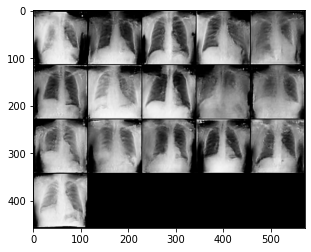

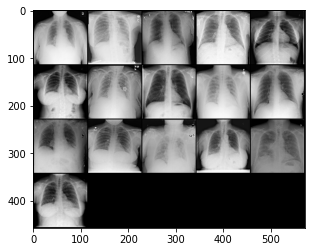

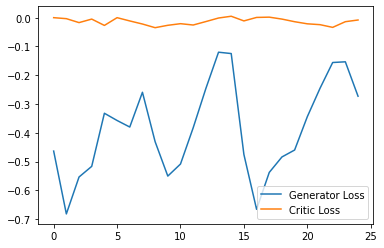

 18%|█████████████▍                                                               | 999/5708 [13:14<1:00:36,  1.29it/s]

Epoch 0, step 1000: Generator loss: -0.4219899525754154, critic loss: -0.009325341562274842


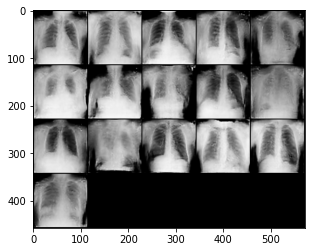

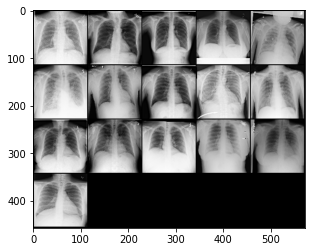

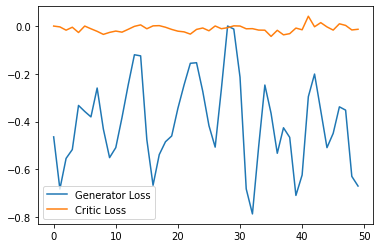

 26%|████████████████████▍                                                         | 1499/5708 [19:50<54:08,  1.30it/s]

Epoch 0, step 1500: Generator loss: -0.2695567144678207, critic loss: -0.01349222177192569


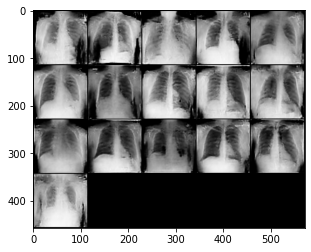

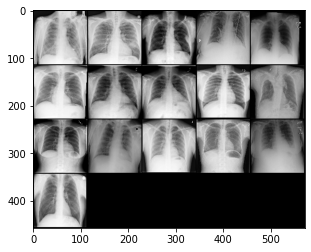

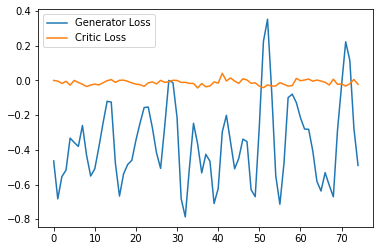

 35%|███████████████████████████▎                                                  | 1999/5708 [26:25<47:50,  1.29it/s]

Epoch 0, step 2000: Generator loss: -0.3159337172023952, critic loss: -0.016061513256467878


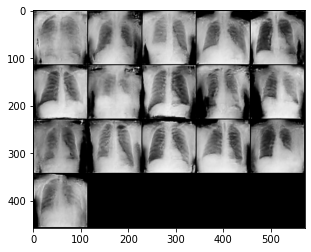

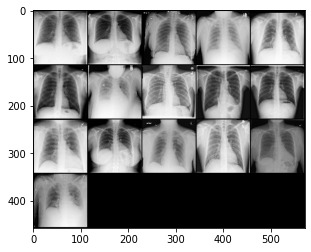

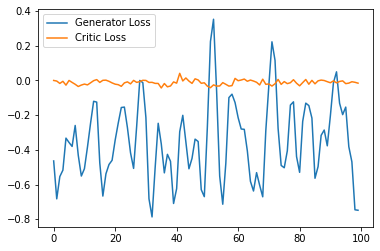

 44%|██████████████████████████████████▏                                           | 2499/5708 [32:54<41:19,  1.29it/s]

Epoch 0, step 2500: Generator loss: -0.5107134432243183, critic loss: -0.011028234595060353


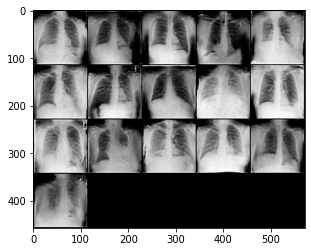

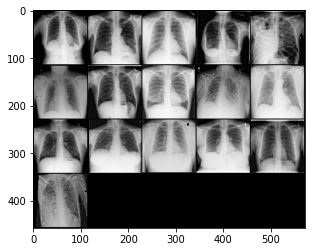

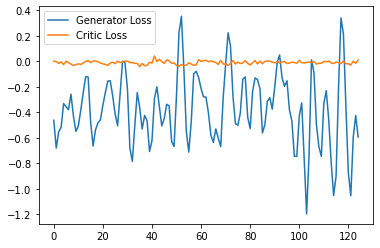

 53%|████████████████████████████████████████▉                                     | 2999/5708 [39:23<34:52,  1.29it/s]

Epoch 0, step 3000: Generator loss: -0.5544675918025896, critic loss: -0.016866056749969705


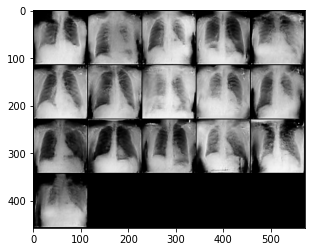

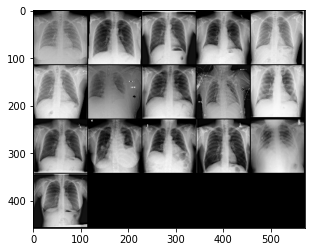

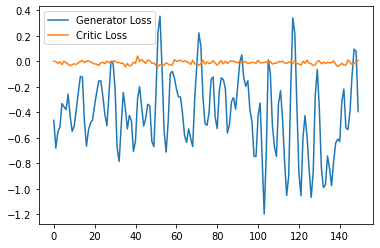

 61%|███████████████████████████████████████████████▊                              | 3499/5708 [45:54<28:27,  1.29it/s]

Epoch 0, step 3500: Generator loss: -0.6277050917780725, critic loss: -0.01501686648204922


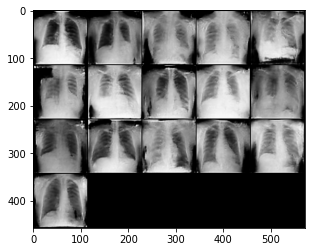

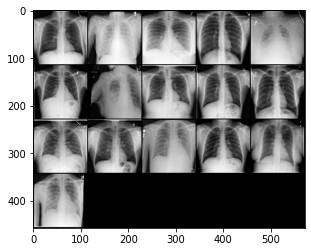

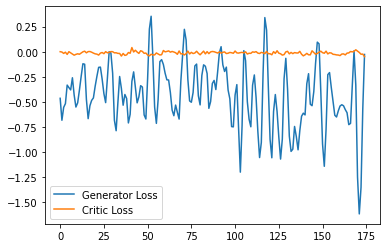

 70%|██████████████████████████████████████████████████████▋                       | 3999/5708 [52:27<22:14,  1.28it/s]

Epoch 0, step 4000: Generator loss: -0.9014927284941078, critic loss: -0.012641249546036125


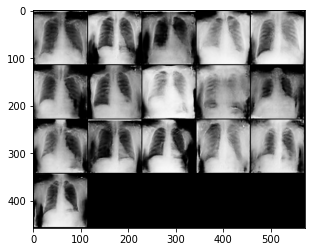

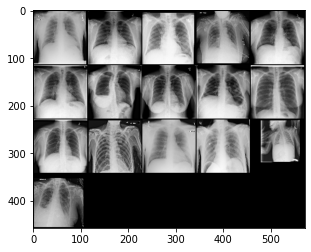

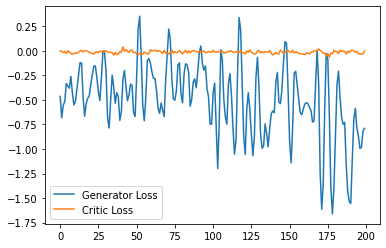

 79%|█████████████████████████████████████████████████████████████▍                | 4499/5708 [58:56<15:36,  1.29it/s]

Epoch 0, step 4500: Generator loss: -0.8271742343902588, critic loss: -0.015610815998911858


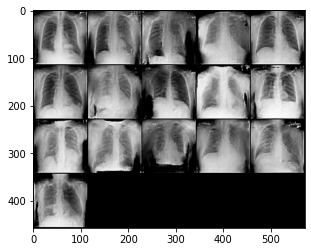

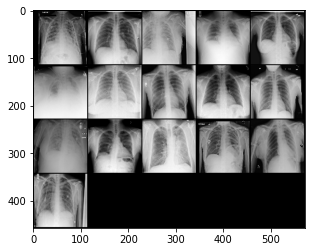

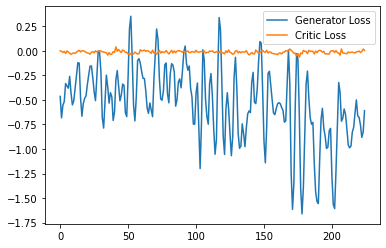

 88%|██████████████████████████████████████████████████████████████████▌         | 4999/5708 [1:05:49<10:38,  1.11it/s]

Epoch 0, step 5000: Generator loss: -0.6480187770915218, critic loss: -0.012135245835408565


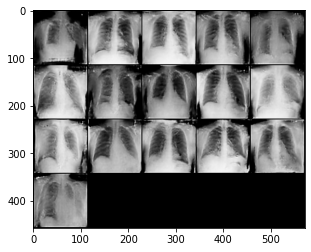

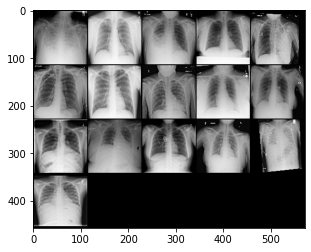

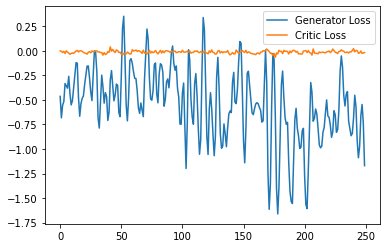

 96%|█████████████████████████████████████████████████████████████████████████▏  | 5499/5708 [1:14:01<07:27,  2.14s/it]

Epoch 0, step 5500: Generator loss: -0.848534927570261, critic loss: -0.007067090684175498


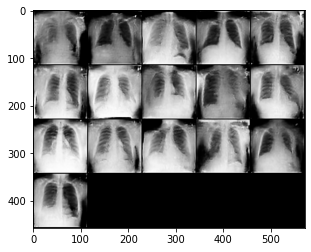

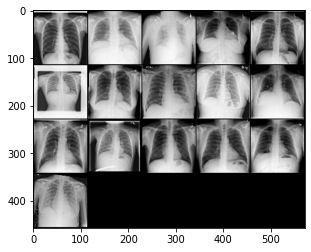

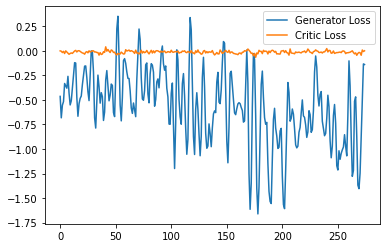

  5%|███▉                                                                         | 291/5708 [03:54<1:09:52,  1.29it/s]

Epoch 1, step 6000: Generator loss: -0.7191425007879734, critic loss: -0.01270565464738757


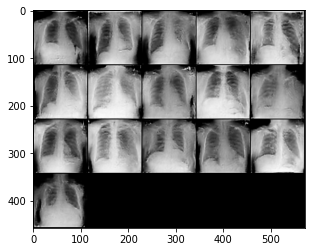

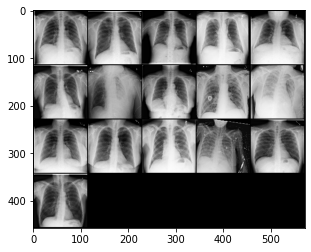

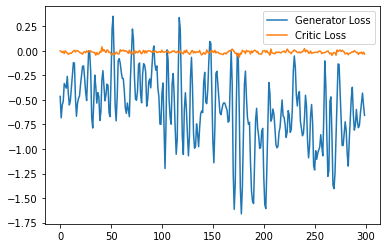

 14%|██████████▋                                                                  | 791/5708 [10:22<1:03:23,  1.29it/s]

Epoch 1, step 6500: Generator loss: -0.7906952958405018, critic loss: -0.01156415643477811


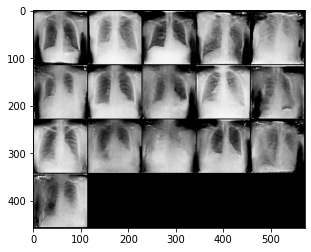

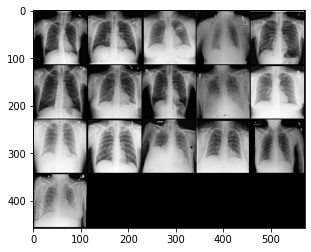

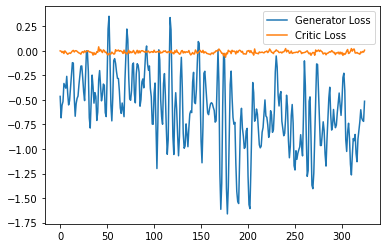

 23%|█████████████████▋                                                            | 1291/5708 [16:49<56:56,  1.29it/s]

Epoch 1, step 7000: Generator loss: -0.933085408091545, critic loss: -0.012228664099425081


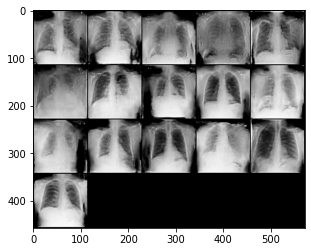

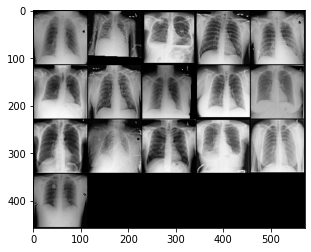

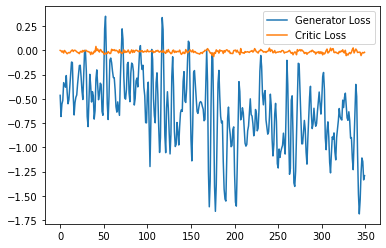

 31%|████████████████████████▍                                                     | 1791/5708 [23:16<50:31,  1.29it/s]

Epoch 1, step 7500: Generator loss: -0.8207561481595039, critic loss: -0.01518227178212255


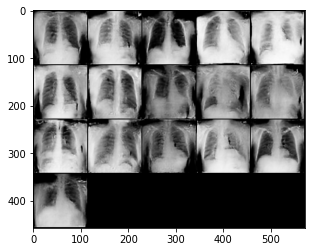

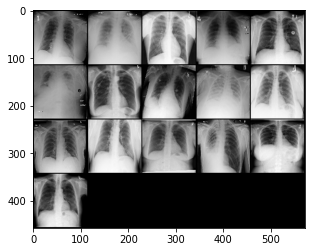

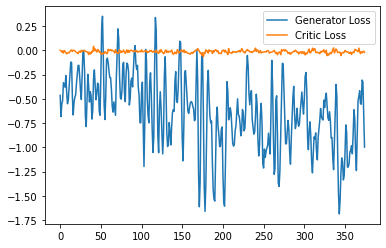

 40%|███████████████████████████████▎                                              | 2291/5708 [29:44<44:03,  1.29it/s]

Epoch 1, step 8000: Generator loss: -0.8070403010547161, critic loss: -0.010818998620659118


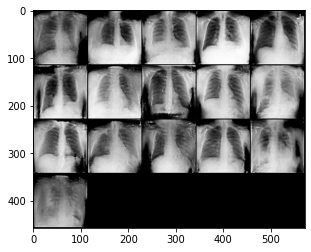

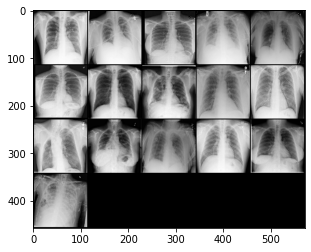

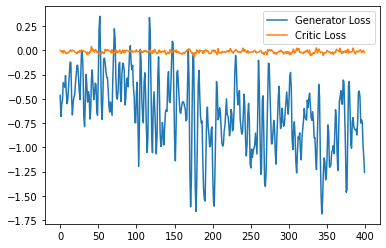

 49%|██████████████████████████████████████▏                                       | 2791/5708 [36:10<37:33,  1.29it/s]

Epoch 1, step 8500: Generator loss: -0.8971853037774563, critic loss: -0.010215188215300453


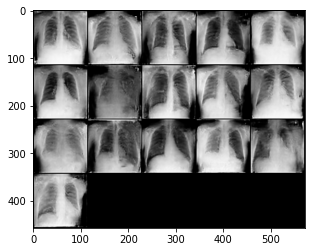

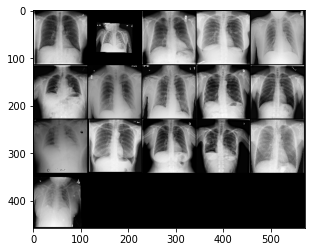

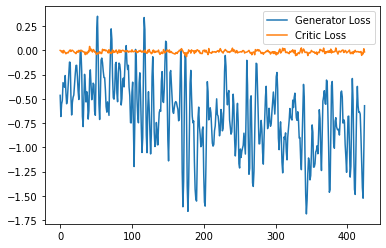

 58%|████████████████████████████████████████████▉                                 | 3291/5708 [42:37<31:10,  1.29it/s]

Epoch 1, step 9000: Generator loss: -0.6694483777154236, critic loss: -0.011917809224128724


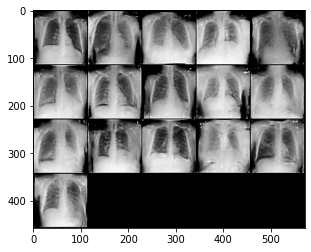

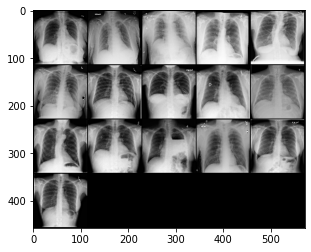

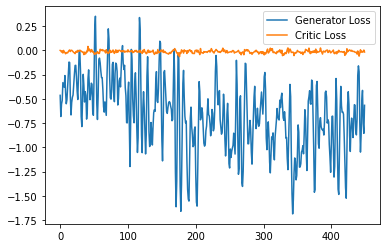

 66%|███████████████████████████████████████████████████▊                          | 3791/5708 [49:05<24:42,  1.29it/s]

Epoch 1, step 9500: Generator loss: -0.7746060103531927, critic loss: -0.009994953505322339


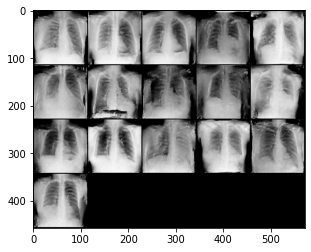

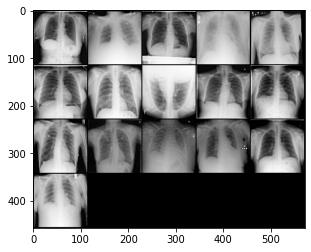

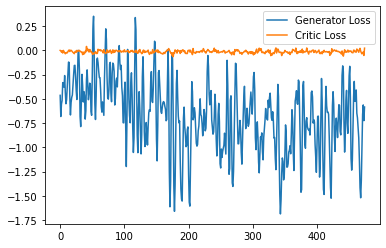

 75%|██████████████████████████████████████████████████████████▋                   | 4291/5708 [55:33<18:17,  1.29it/s]

Epoch 1, step 10000: Generator loss: -0.897461843252182, critic loss: -0.010436436794698238


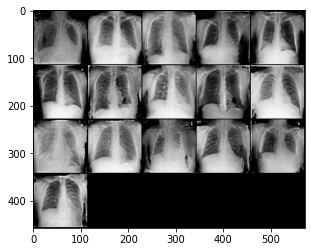

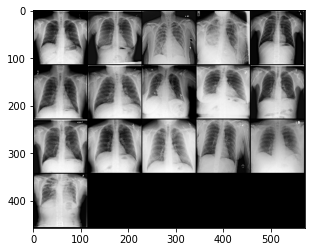

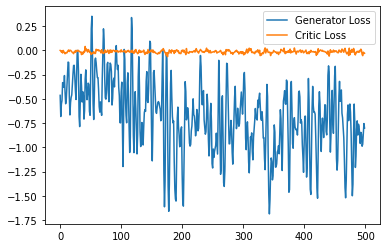

 84%|███████████████████████████████████████████████████████████████▊            | 4791/5708 [1:02:00<11:48,  1.29it/s]

Epoch 1, step 10500: Generator loss: -0.9788307177722454, critic loss: -0.013983833501674243


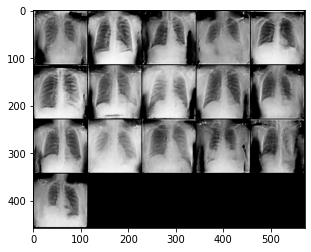

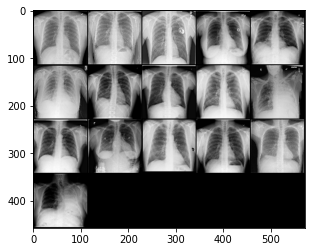

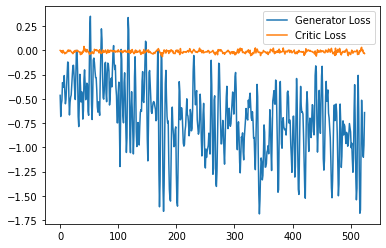

 93%|██████████████████████████████████████████████████████████████████████▍     | 5291/5708 [1:08:26<05:22,  1.29it/s]

Epoch 1, step 11000: Generator loss: -0.6041648113123956, critic loss: -0.01329459519460797


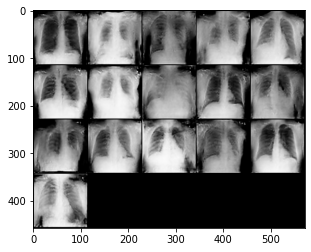

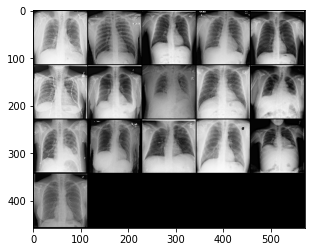

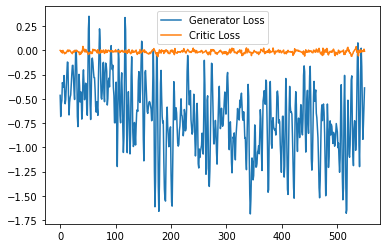

  1%|█▏                                                                            | 83/5708 [01:12<1:12:29,  1.29it/s]

Epoch 2, step 11500: Generator loss: -0.5109569254070521, critic loss: -0.017538162480667238


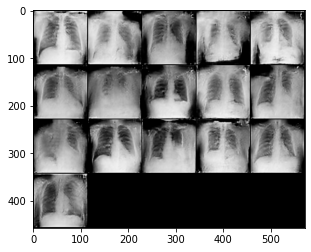

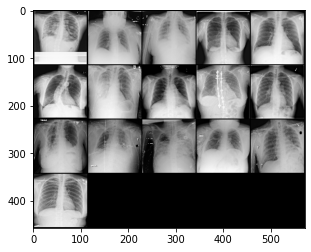

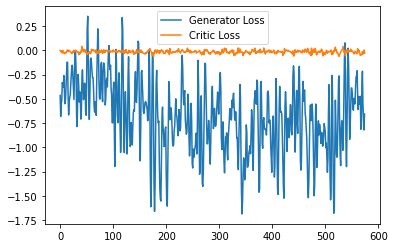

 10%|███████▊                                                                     | 583/5708 [07:41<1:06:05,  1.29it/s]

Epoch 2, step 12000: Generator loss: -0.7132310163555666, critic loss: -0.011936767189949751


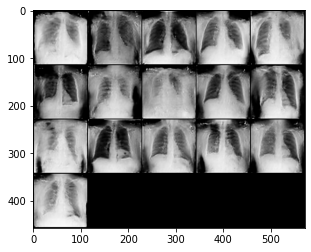

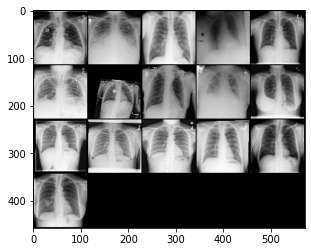

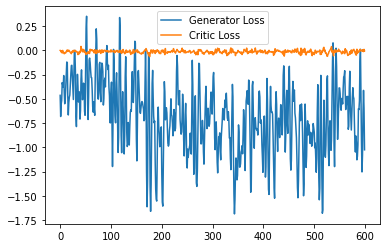

 19%|██████████████▊                                                               | 1083/5708 [14:08<59:33,  1.29it/s]

Epoch 2, step 12500: Generator loss: -0.6361991401091218, critic loss: -0.009844711178727454


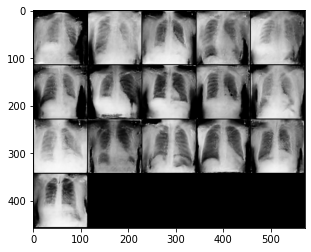

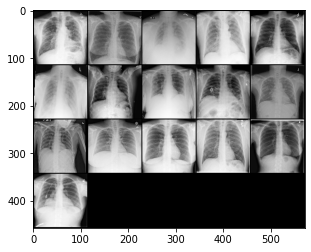

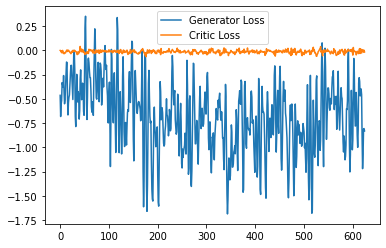

 28%|█████████████████████▋                                                        | 1583/5708 [20:34<53:07,  1.29it/s]

Epoch 2, step 13000: Generator loss: -0.870510959982872, critic loss: -0.012431191459670652


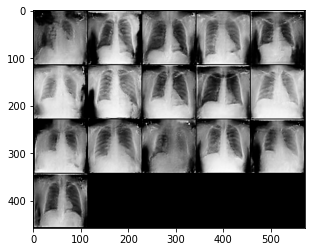

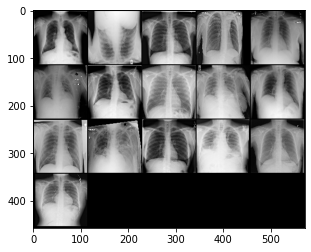

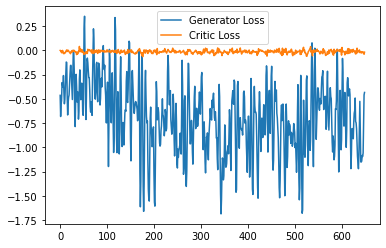

 36%|████████████████████████████▍                                                 | 2083/5708 [27:01<46:40,  1.29it/s]

Epoch 2, step 13500: Generator loss: -0.7667043722867966, critic loss: -0.008733173601236184


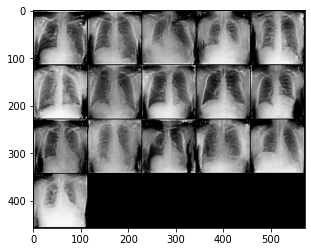

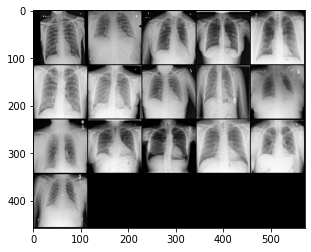

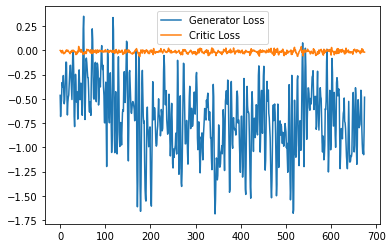

 45%|███████████████████████████████████▎                                          | 2583/5708 [33:28<40:17,  1.29it/s]

Epoch 2, step 14000: Generator loss: -0.6887417515302077, critic loss: -0.008233426679437982


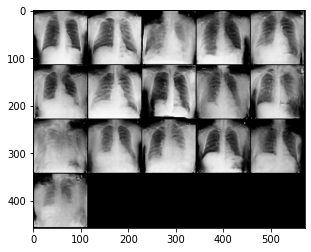

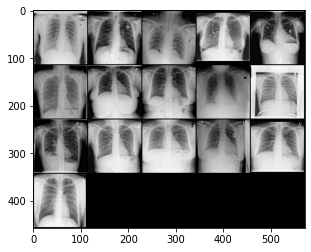

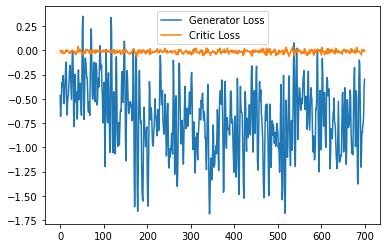

 54%|██████████████████████████████████████████▏                                   | 3083/5708 [39:55<33:49,  1.29it/s]

Epoch 2, step 14500: Generator loss: -0.8569578325301409, critic loss: -0.015219538711197671


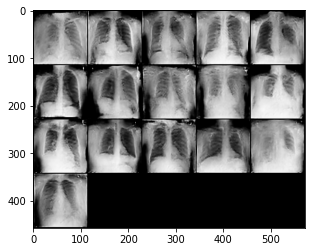

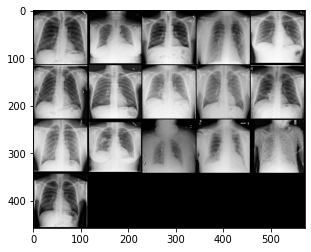

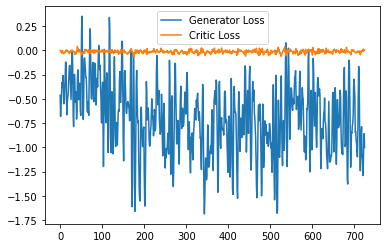

 63%|████████████████████████████████████████████████▉                             | 3583/5708 [46:23<27:23,  1.29it/s]

Epoch 2, step 15000: Generator loss: -1.0192867969870567, critic loss: -0.011441837911773473


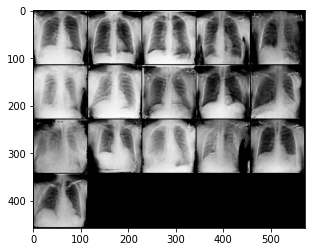

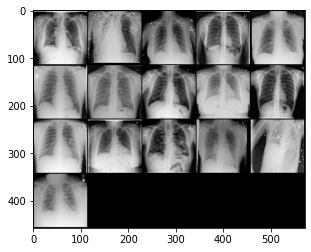

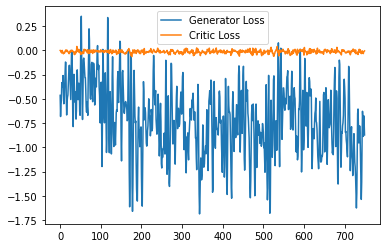

 72%|███████████████████████████████████████████████████████▊                      | 4083/5708 [52:50<20:55,  1.29it/s]

Epoch 2, step 15500: Generator loss: -0.4533942937037209, critic loss: -0.011270974449068305


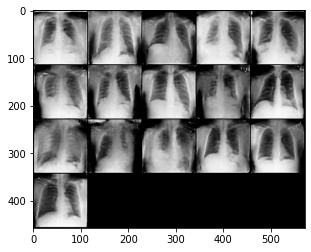

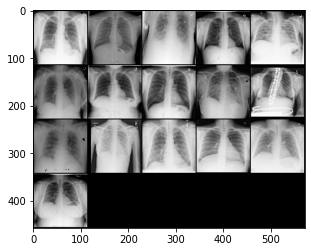

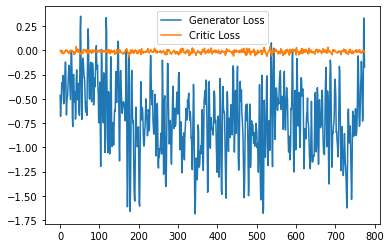

 80%|██████████████████████████████████████████████████████████████▋               | 4583/5708 [59:17<14:30,  1.29it/s]

Epoch 2, step 16000: Generator loss: 0.053076031964352295, critic loss: -0.011588387683266775


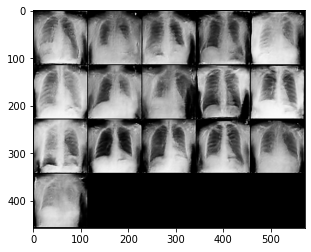

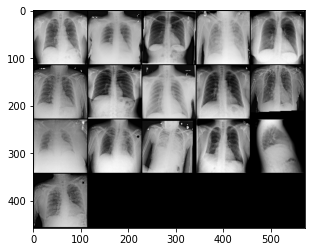

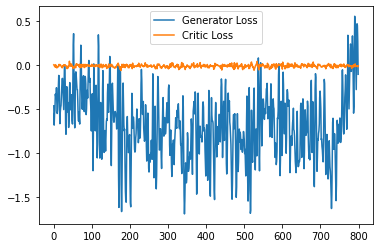

 89%|███████████████████████████████████████████████████████████████████▋        | 5083/5708 [1:05:44<08:03,  1.29it/s]

Epoch 2, step 16500: Generator loss: -0.10937000970449298, critic loss: -0.012272892480343585


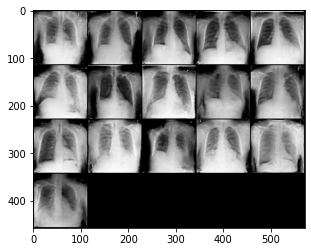

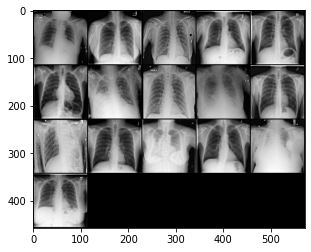

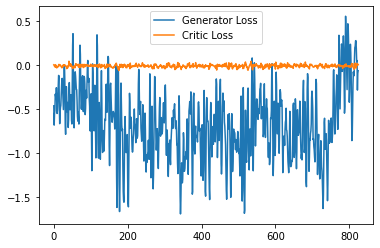

 98%|██████████████████████████████████████████████████████████████████████████▎ | 5583/5708 [1:12:11<01:36,  1.29it/s]

Epoch 2, step 17000: Generator loss: -0.034200908879982304, critic loss: -0.004231705511920157


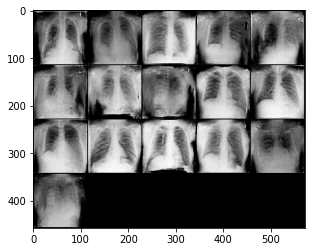

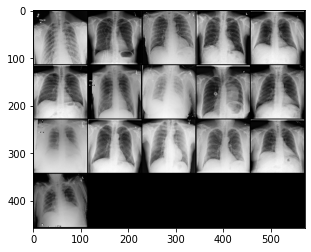

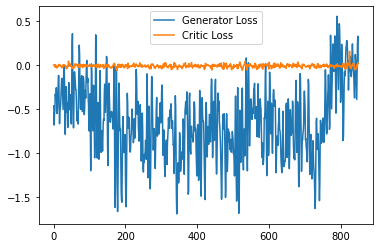

  7%|█████                                                                        | 375/5708 [04:59<1:08:53,  1.29it/s]

Epoch 3, step 17500: Generator loss: -0.3281371616353281, critic loss: -0.010498611297830944


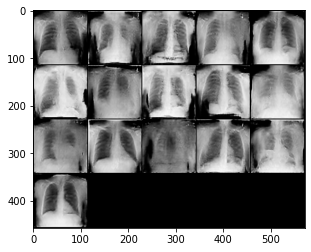

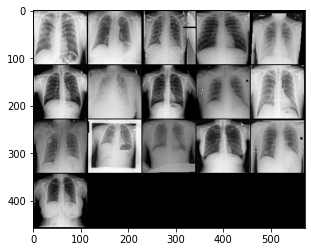

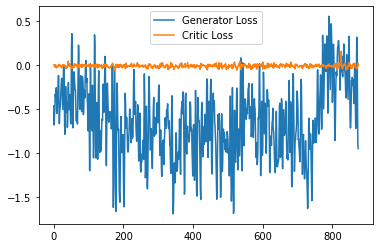

 15%|███████████▊                                                                 | 875/5708 [11:27<1:02:22,  1.29it/s]

Epoch 3, step 18000: Generator loss: -0.4621948802759871, critic loss: -0.015268617512658237


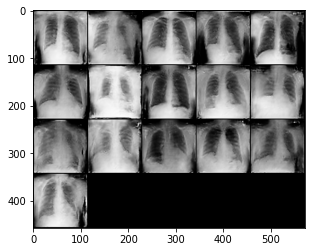

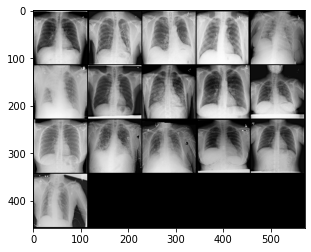

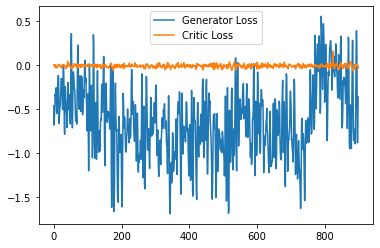

 24%|██████████████████▊                                                           | 1375/5708 [17:54<55:49,  1.29it/s]

Epoch 3, step 18500: Generator loss: -0.4780776172559708, critic loss: -0.00976528330799192


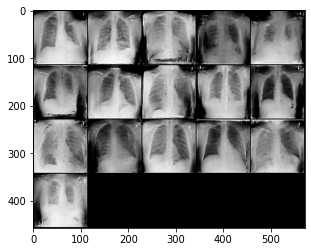

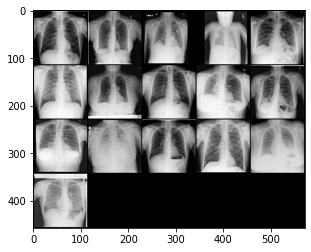

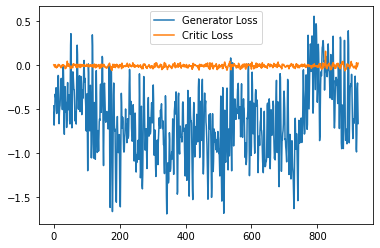

 33%|█████████████████████████▌                                                    | 1875/5708 [24:21<49:23,  1.29it/s]

Epoch 3, step 19000: Generator loss: -0.19446636433772074, critic loss: -0.011328597675729541


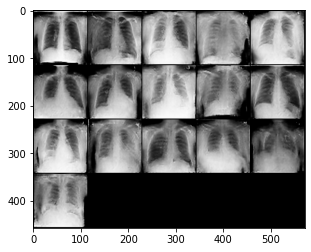

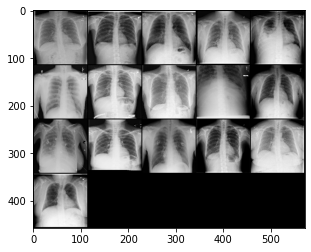

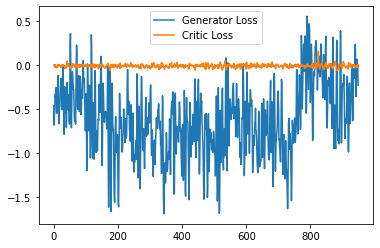

 42%|████████████████████████████████▍                                             | 2375/5708 [30:48<42:55,  1.29it/s]

Epoch 3, step 19500: Generator loss: -0.2575991300903261, critic loss: -0.01160793289123102


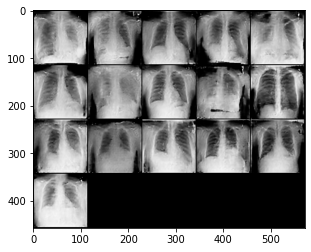

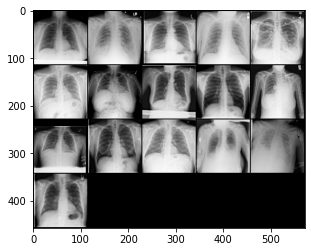

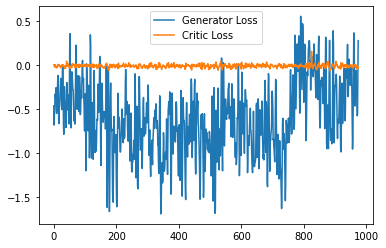

 50%|███████████████████████████████████████▎                                      | 2875/5708 [37:15<36:32,  1.29it/s]

Epoch 3, step 20000: Generator loss: -0.12511183973911102, critic loss: -0.012482829925976699


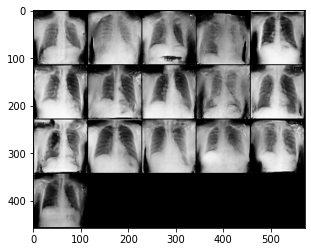

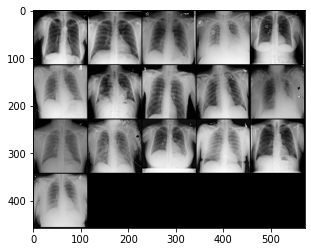

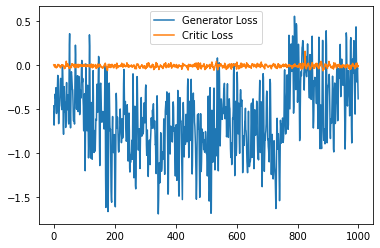

 59%|██████████████████████████████████████████████                                | 3375/5708 [43:42<30:04,  1.29it/s]

Epoch 3, step 20500: Generator loss: 0.17441624691849575, critic loss: -0.01611285844445227


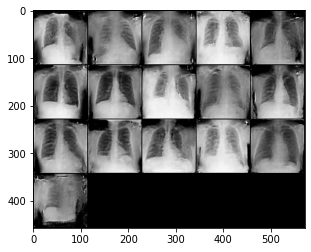

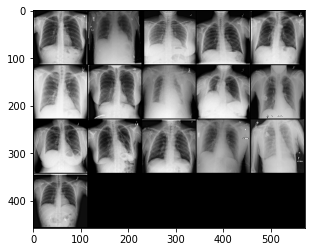

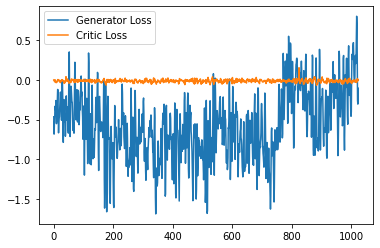

 68%|████████████████████████████████████████████████████▉                         | 3875/5708 [50:09<23:35,  1.29it/s]

Epoch 3, step 21000: Generator loss: -0.03370120178279467, critic loss: -0.010445517827570434


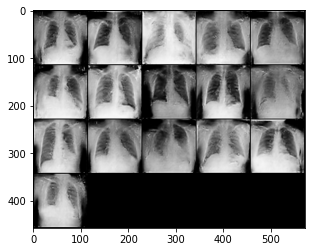

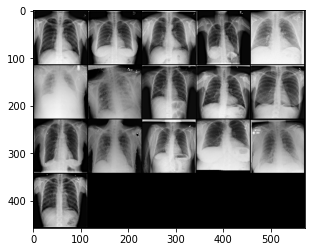

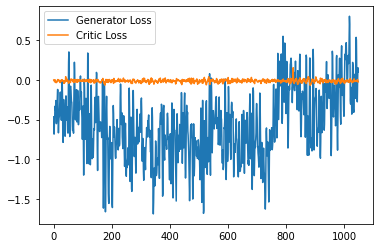

 77%|███████████████████████████████████████████████████████████▊                  | 4375/5708 [56:37<17:10,  1.29it/s]

Epoch 3, step 21500: Generator loss: 0.10577334000102565, critic loss: -0.01824393215794116


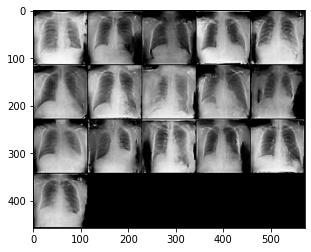

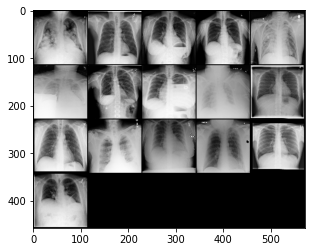

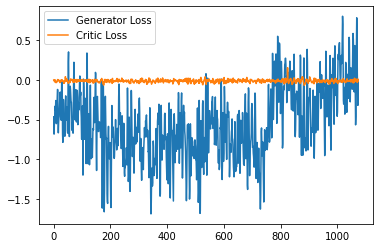

 85%|████████████████████████████████████████████████████████████████▉           | 4875/5708 [1:03:04<10:44,  1.29it/s]

Epoch 3, step 22000: Generator loss: -0.2940822072001174, critic loss: -0.009101428931392737


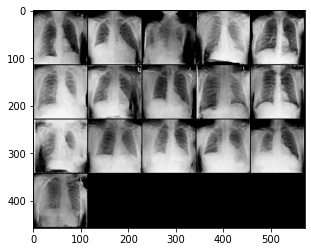

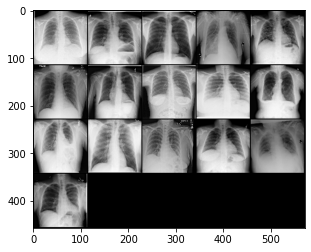

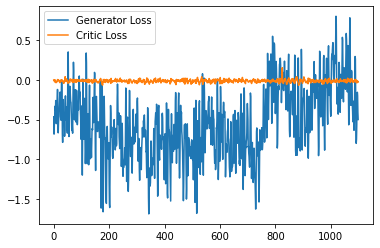

 94%|███████████████████████████████████████████████████████████████████████▌    | 5375/5708 [1:09:31<04:17,  1.30it/s]

Epoch 3, step 22500: Generator loss: -0.535372158595128, critic loss: -0.011894888352416458


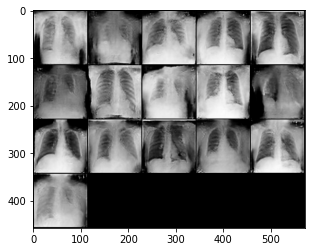

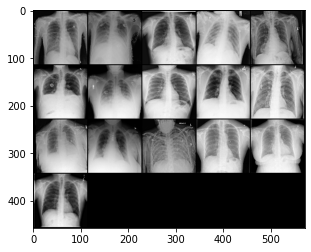

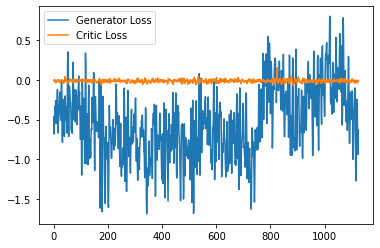

  3%|██▎                                                                          | 167/5708 [02:18<1:11:35,  1.29it/s]

Epoch 4, step 23000: Generator loss: -0.5737614749222993, critic loss: -0.012470352565497164


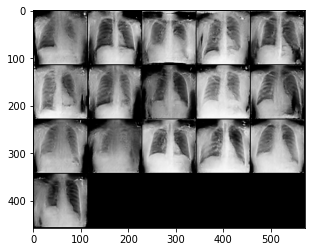

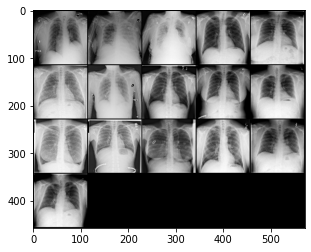

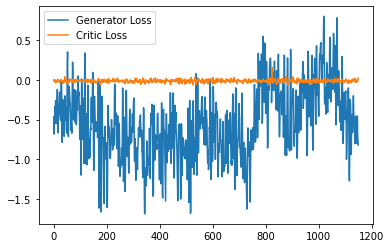

 12%|████████▉                                                                    | 667/5708 [08:46<1:05:06,  1.29it/s]

Epoch 4, step 23500: Generator loss: -0.5089286072039977, critic loss: -0.009278356430213892


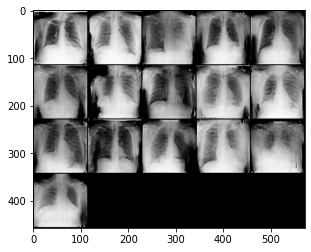

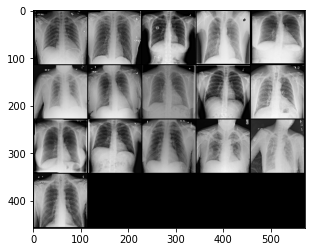

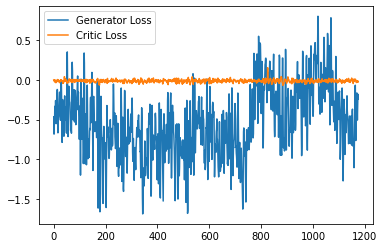

 20%|███████████████▉                                                              | 1167/5708 [15:14<58:38,  1.29it/s]

Epoch 4, step 24000: Generator loss: -0.23235037217941135, critic loss: -0.013791755095496771


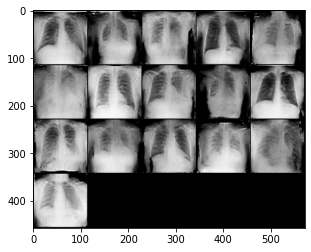

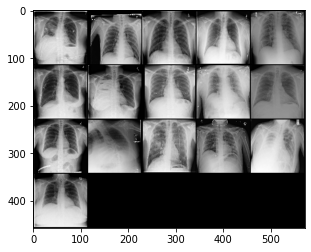

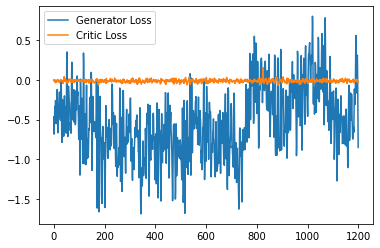

 29%|██████████████████████▊                                                       | 1667/5708 [21:42<52:10,  1.29it/s]

Epoch 4, step 24500: Generator loss: -0.5210926922578365, critic loss: -0.009498161920346302


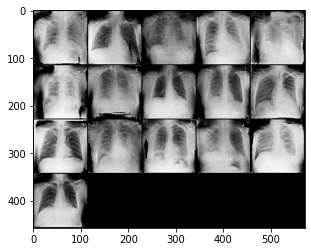

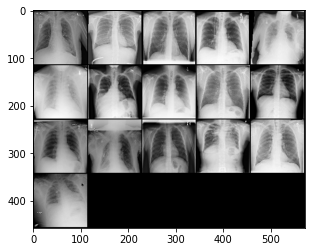

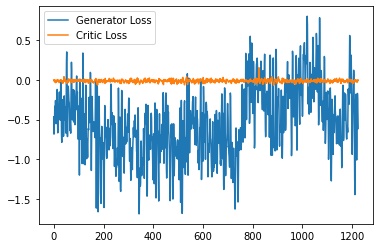

 38%|█████████████████████████████▌                                                | 2167/5708 [28:10<45:43,  1.29it/s]

Epoch 4, step 25000: Generator loss: -0.718069762378931, critic loss: -0.0014096547255292565


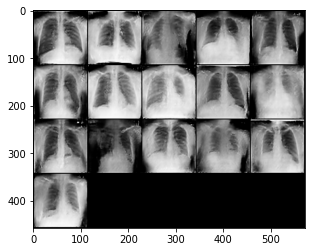

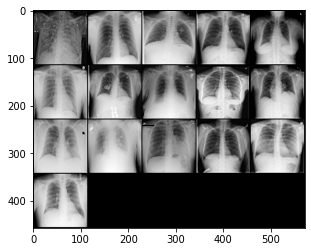

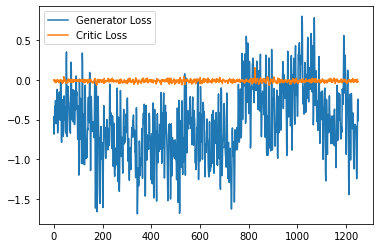

 47%|████████████████████████████████████▍                                         | 2667/5708 [34:38<39:17,  1.29it/s]

Epoch 4, step 25500: Generator loss: -0.427698805058375, critic loss: -0.008221455039083963


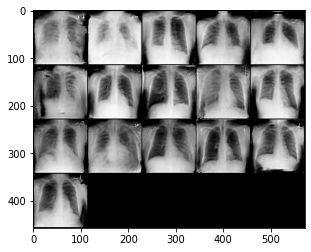

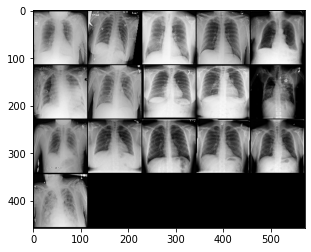

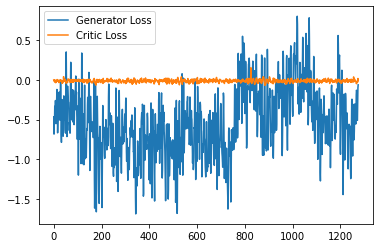

 55%|███████████████████████████████████████████▎                                  | 3167/5708 [41:06<32:49,  1.29it/s]

Epoch 4, step 26000: Generator loss: -0.11251184592233039, critic loss: -0.009019366529770206


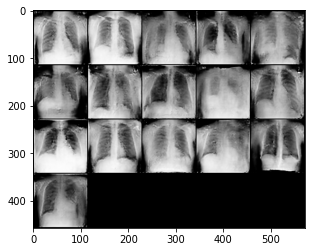

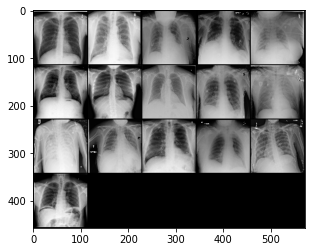

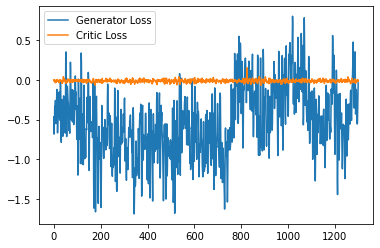

 64%|██████████████████████████████████████████████████                            | 3667/5708 [47:34<26:22,  1.29it/s]

Epoch 4, step 26500: Generator loss: -0.03212157759699039, critic loss: -0.011255042395740756


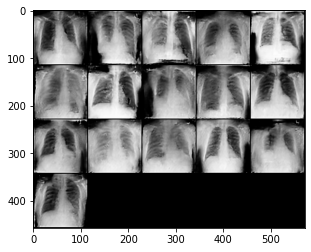

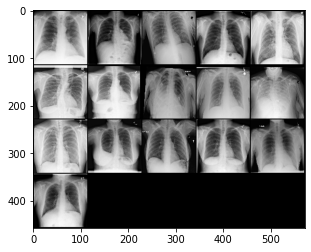

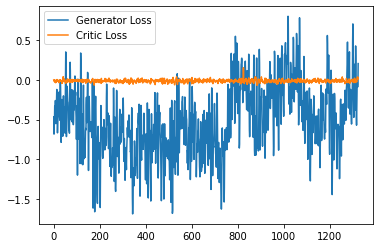

 73%|████████████████████████████████████████████████████████▉                     | 4167/5708 [54:03<19:55,  1.29it/s]

Epoch 4, step 27000: Generator loss: 0.18799820553092286, critic loss: -0.007148113407567141


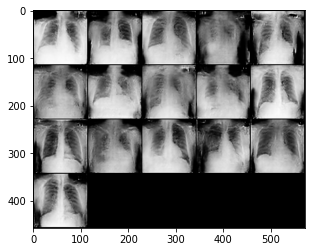

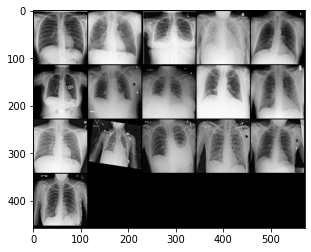

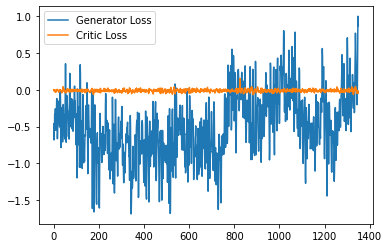

 82%|██████████████████████████████████████████████████████████████▏             | 4667/5708 [1:00:31<13:26,  1.29it/s]

Epoch 4, step 27500: Generator loss: 0.35562903226050546, critic loss: -0.008854924303106968


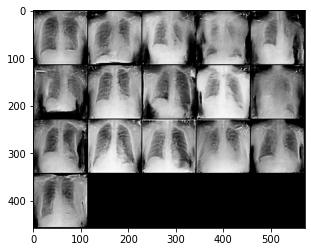

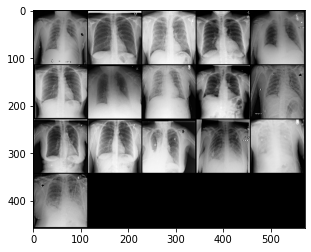

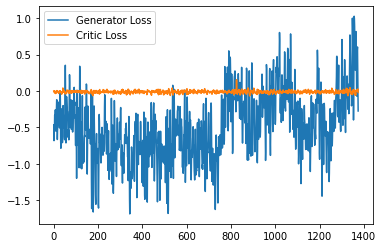

 91%|████████████████████████████████████████████████████████████████████▊       | 5167/5708 [1:06:59<06:59,  1.29it/s]

Epoch 4, step 28000: Generator loss: 0.3591788944225991, critic loss: -0.012724780966900284


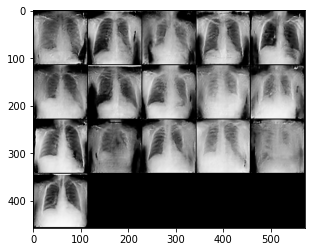

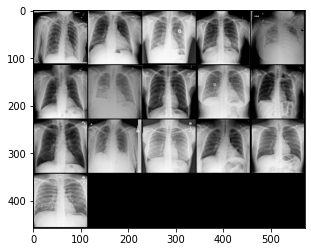

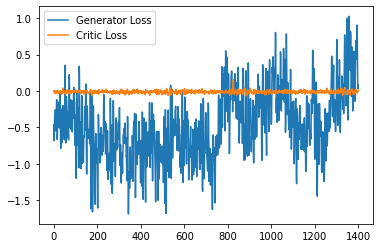

 99%|███████████████████████████████████████████████████████████████████████████▍| 5667/5708 [1:13:28<00:31,  1.29it/s]

Epoch 4, step 28500: Generator loss: 0.3680906075909734, critic loss: 0.0014832999040372665


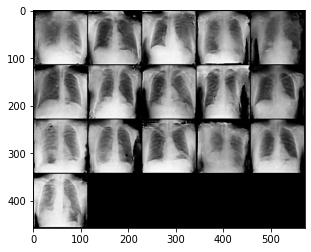

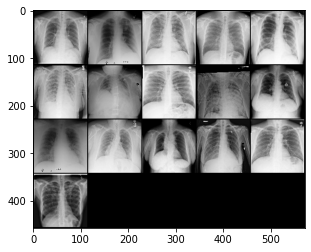

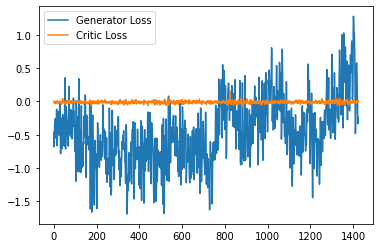

  8%|██████▏                                                                      | 459/5708 [06:04<1:07:49,  1.29it/s]

Epoch 5, step 29000: Generator loss: 0.39756465653449413, critic loss: -0.0038877782931551357


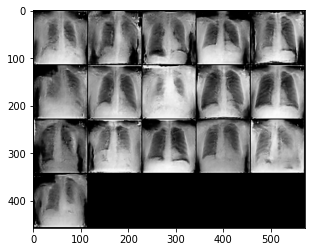

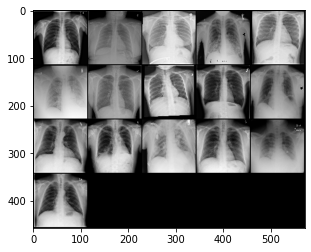

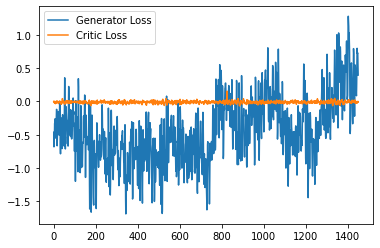

 17%|████████████▉                                                                | 959/5708 [12:33<1:01:22,  1.29it/s]

Epoch 5, step 29500: Generator loss: 0.5244097699671983, critic loss: -0.004193796102702616


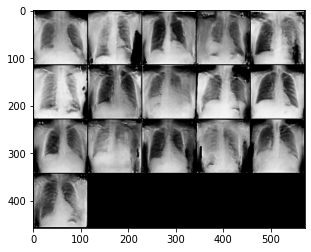

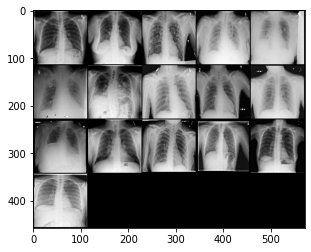

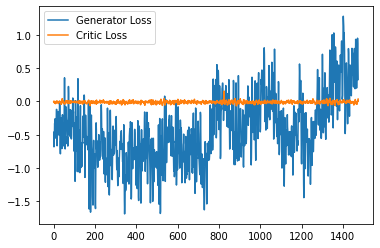

 26%|███████████████████▉                                                          | 1459/5708 [19:01<54:56,  1.29it/s]

Epoch 5, step 30000: Generator loss: 0.38906212751858404, critic loss: -0.002554667844157666


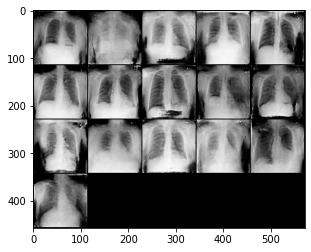

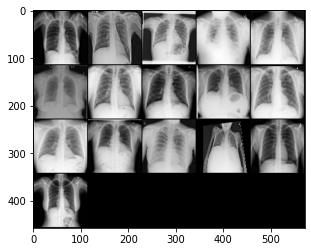

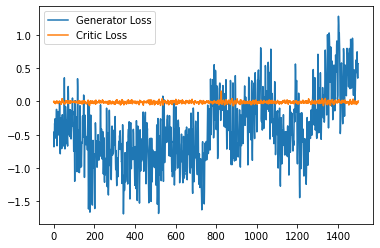

 34%|██████████████████████████▊                                                   | 1959/5708 [25:30<48:31,  1.29it/s]

Epoch 5, step 30500: Generator loss: 0.4362773065418005, critic loss: -0.017020985619910053


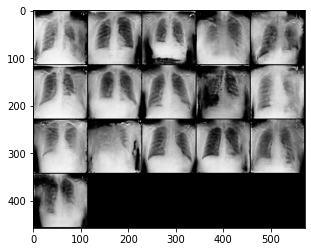

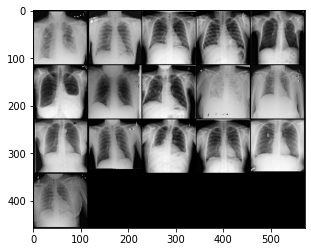

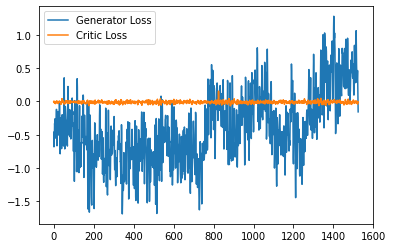

 43%|█████████████████████████████████▌                                            | 2459/5708 [32:02<42:35,  1.27it/s]

Epoch 5, step 31000: Generator loss: 0.20313267089356668, critic loss: -0.014195446327887473


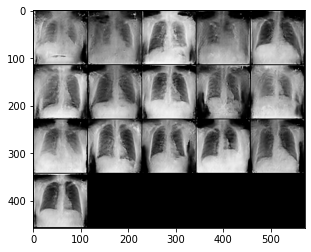

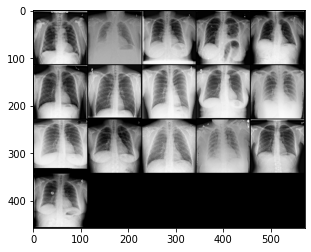

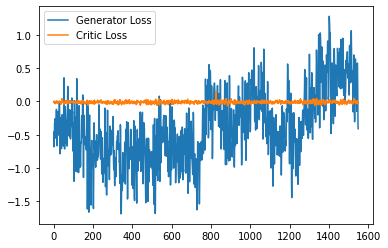

 52%|████████████████████████████████████████▍                                     | 2959/5708 [38:36<35:58,  1.27it/s]

Epoch 5, step 31500: Generator loss: -0.16811441012239084, critic loss: -0.006846074324101211


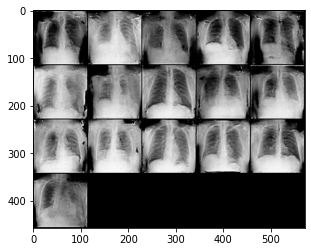

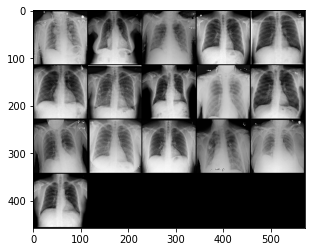

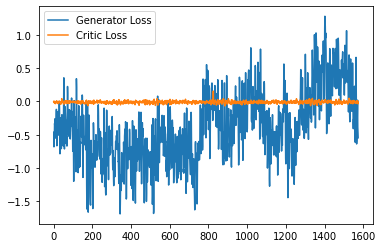

 61%|███████████████████████████████████████████████▎                              | 3459/5708 [45:08<29:18,  1.28it/s]

Epoch 5, step 32000: Generator loss: -0.10761809197731782, critic loss: -0.007862767792306834


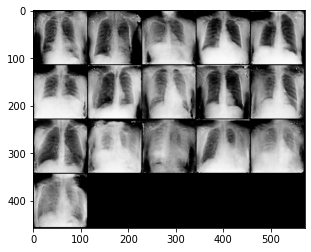

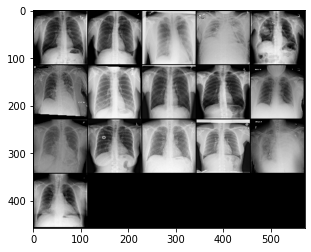

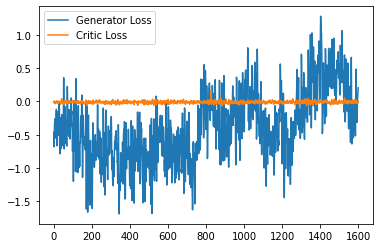

 69%|██████████████████████████████████████████████████████                        | 3959/5708 [51:40<22:43,  1.28it/s]

Epoch 5, step 32500: Generator loss: 0.42297210125904533, critic loss: 0.0005094802297651766


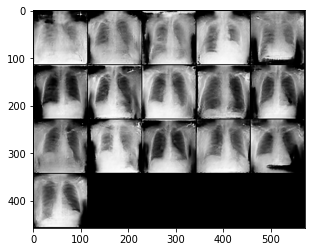

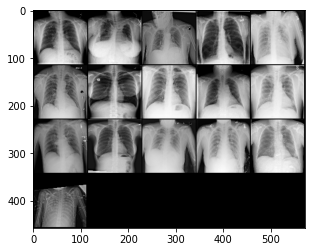

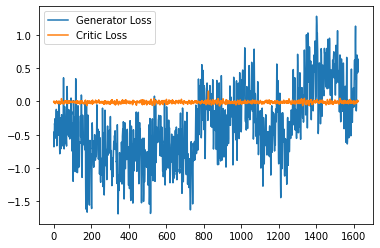

 78%|████████████████████████████████████████████████████████████▉                 | 4459/5708 [58:09<16:10,  1.29it/s]

Epoch 5, step 33000: Generator loss: 0.15145946214150172, critic loss: -0.001987214212026448


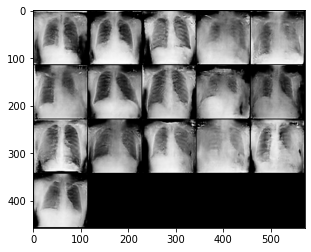

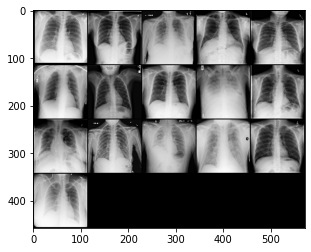

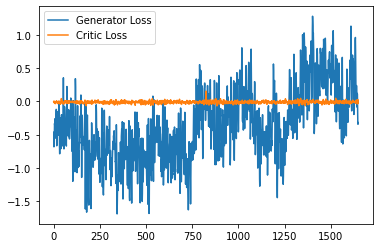

 87%|██████████████████████████████████████████████████████████████████          | 4959/5708 [1:04:38<09:41,  1.29it/s]

Epoch 5, step 33500: Generator loss: 0.22565969845672953, critic loss: -0.0022260255402885344


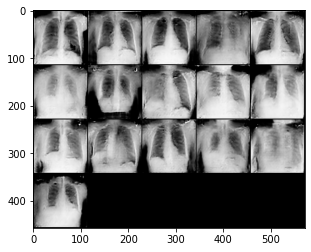

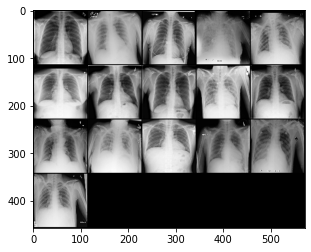

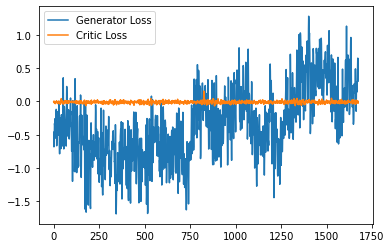

 96%|████████████████████████████████████████████████████████████████████████▋   | 5459/5708 [1:11:07<03:13,  1.29it/s]

Epoch 5, step 34000: Generator loss: 0.13326912534993607, critic loss: -0.0025062681376934073


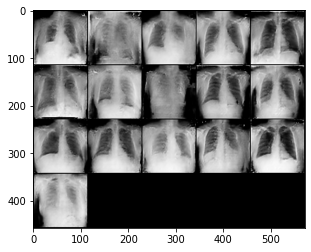

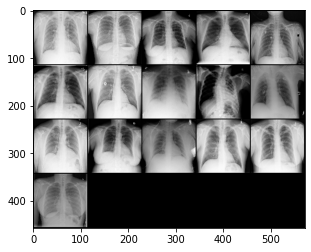

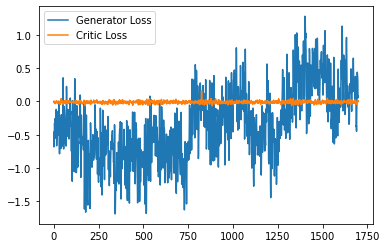

  4%|███▍                                                                         | 251/5708 [03:23<1:10:37,  1.29it/s]

Epoch 6, step 34500: Generator loss: 0.36697855227664694, critic loss: -0.003414757684338837


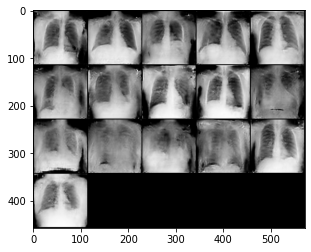

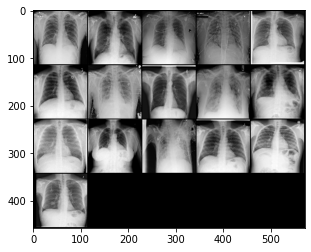

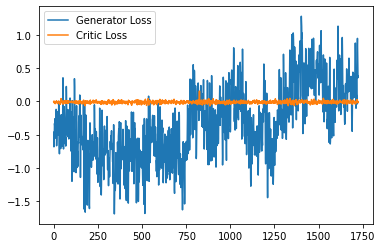

 13%|██████████▏                                                                  | 751/5708 [09:52<1:04:05,  1.29it/s]

Epoch 6, step 35000: Generator loss: 0.2383116566790268, critic loss: -0.009856476106867212


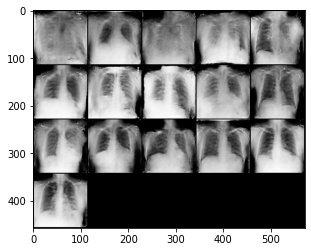

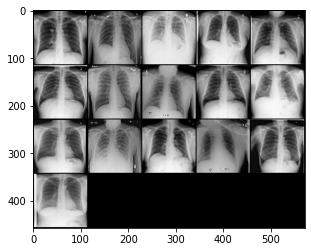

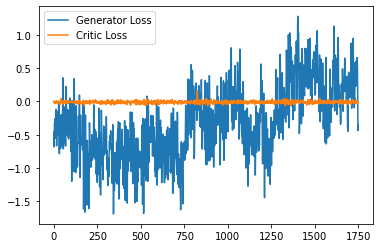

 22%|█████████████████                                                             | 1251/5708 [16:21<57:38,  1.29it/s]

Epoch 6, step 35500: Generator loss: 0.017353890694561416, critic loss: -0.006070834335032851


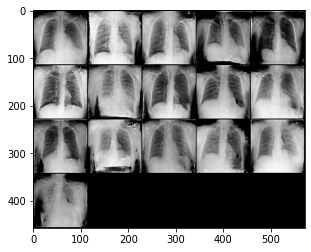

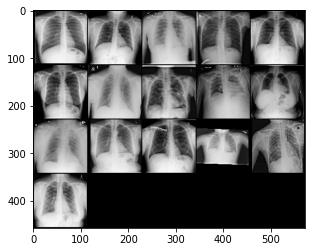

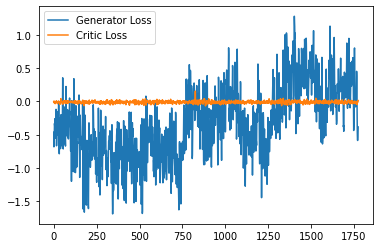

 31%|███████████████████████▉                                                      | 1751/5708 [22:49<51:05,  1.29it/s]

Epoch 6, step 36000: Generator loss: -0.5230473179635592, critic loss: -0.006686714080441746


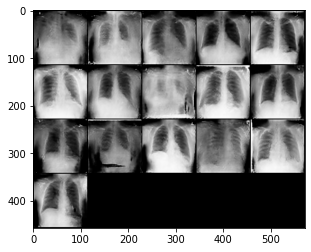

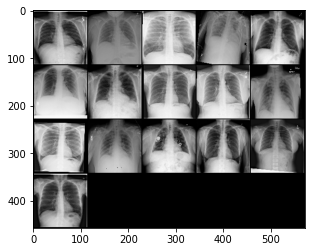

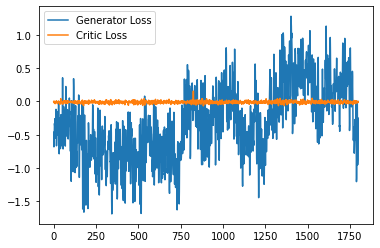

 39%|██████████████████████████████▊                                               | 2251/5708 [29:17<44:37,  1.29it/s]

Epoch 6, step 36500: Generator loss: -0.6038459504349157, critic loss: -0.007715976780932395


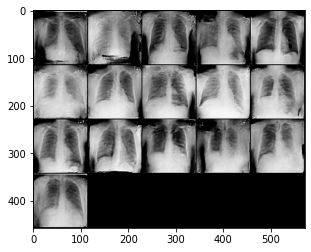

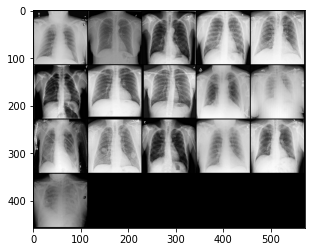

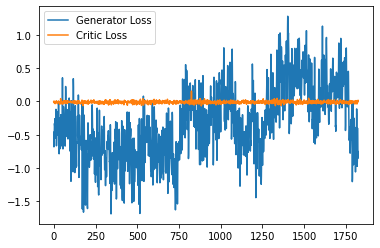

 48%|█████████████████████████████████████▌                                        | 2751/5708 [35:45<38:07,  1.29it/s]

Epoch 6, step 37000: Generator loss: -0.5661170820500702, critic loss: -0.009213518910482521


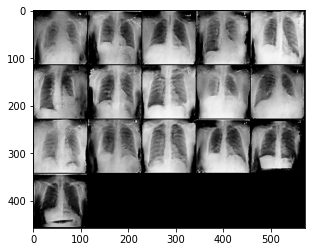

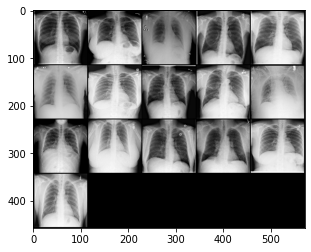

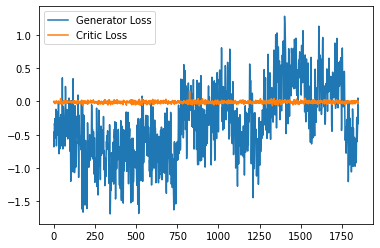

 57%|████████████████████████████████████████████▍                                 | 3251/5708 [42:13<31:42,  1.29it/s]

Epoch 6, step 37500: Generator loss: -0.7117938890648075, critic loss: -0.006250686698034407


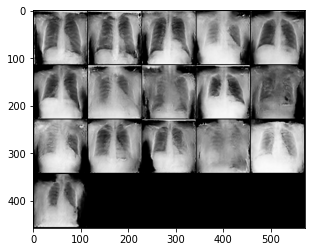

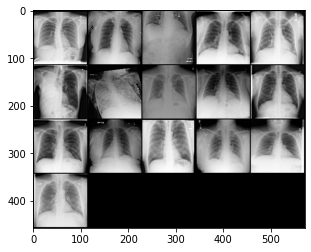

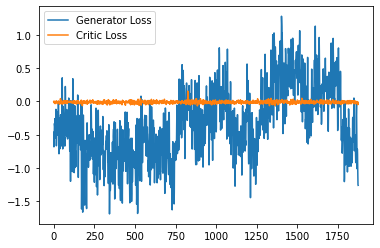

 66%|███████████████████████████████████████████████████▎                          | 3751/5708 [48:41<25:15,  1.29it/s]

Epoch 6, step 38000: Generator loss: -0.5837742298096419, critic loss: -0.006327065517008305


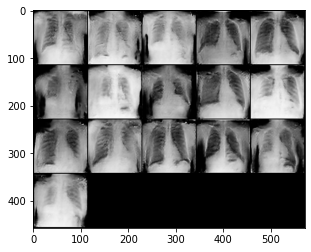

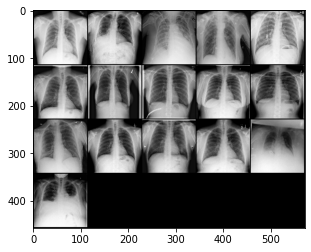

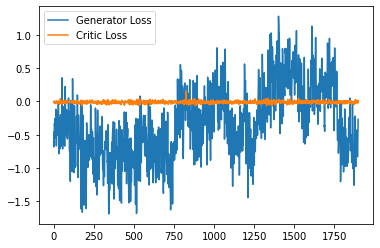

 74%|██████████████████████████████████████████████████████████                    | 4251/5708 [55:09<18:49,  1.29it/s]

Epoch 6, step 38500: Generator loss: -0.4757459745402448, critic loss: -0.006095287344977256


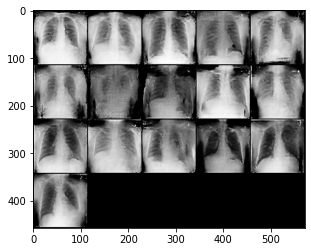

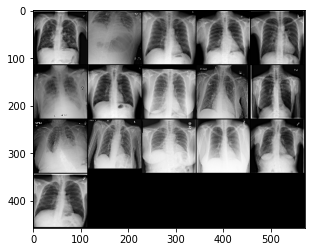

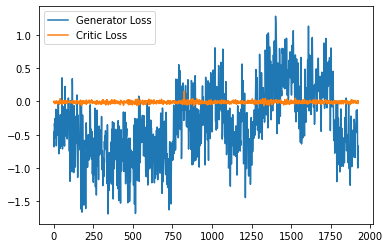

 83%|███████████████████████████████████████████████████████████████▎            | 4751/5708 [1:01:37<12:21,  1.29it/s]

Epoch 6, step 39000: Generator loss: -0.4443579911068082, critic loss: -0.010882732102461158


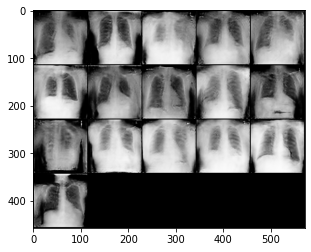

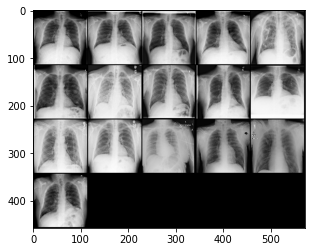

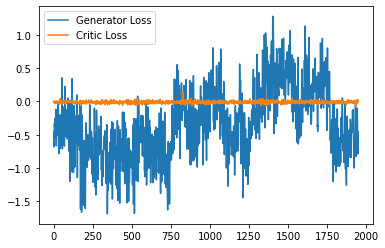

 92%|█████████████████████████████████████████████████████████████████████▉      | 5251/5708 [1:08:05<05:53,  1.29it/s]

Epoch 6, step 39500: Generator loss: -0.3217806437467225, critic loss: -0.006005546862166375


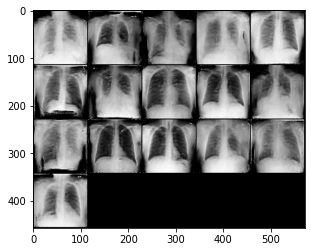

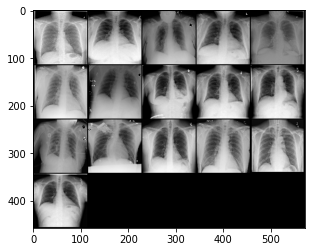

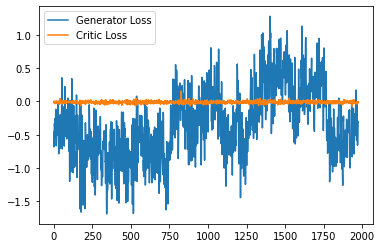

  1%|▌                                                                             | 43/5708 [00:41<1:13:00,  1.29it/s]

Epoch 7, step 40000: Generator loss: -0.44530778218619527, critic loss: -0.007459153631702065


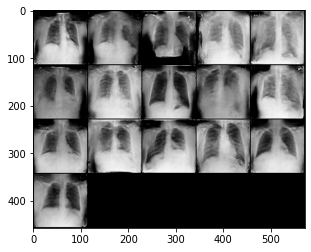

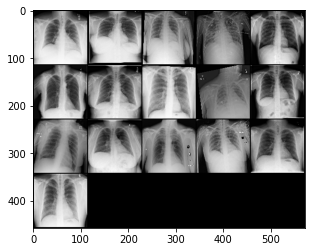

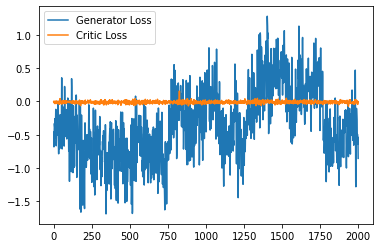

 10%|███████▎                                                                     | 543/5708 [07:10<1:06:39,  1.29it/s]

Epoch 7, step 40500: Generator loss: -0.41835712294111727, critic loss: -0.005020332587976006


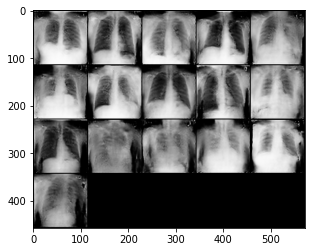

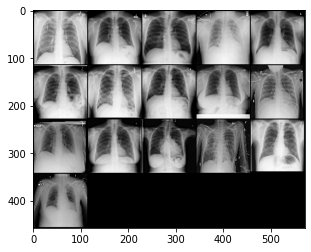

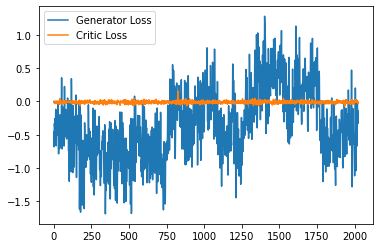

 18%|█████████████▉                                                              | 1043/5708 [13:37<1:00:11,  1.29it/s]

Epoch 7, step 41000: Generator loss: -0.7504392493963241, critic loss: -0.007847411306947464


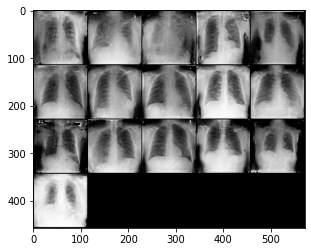

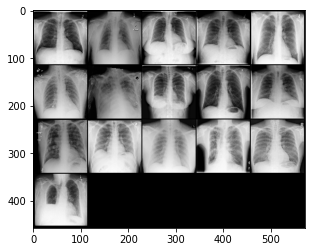

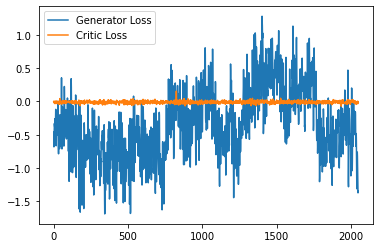

 27%|█████████████████████                                                         | 1543/5708 [20:05<53:46,  1.29it/s]

Epoch 7, step 41500: Generator loss: -0.9347779656201601, critic loss: -0.01104436576869339


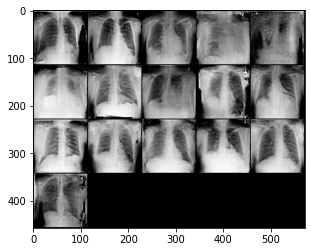

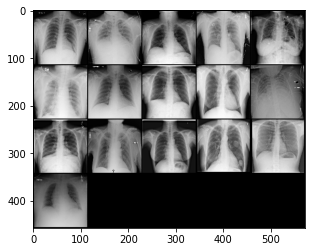

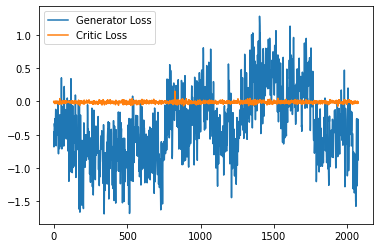

 36%|███████████████████████████▉                                                  | 2043/5708 [26:33<47:18,  1.29it/s]

Epoch 7, step 42000: Generator loss: -0.4900707420520484, critic loss: -0.008528710233420132


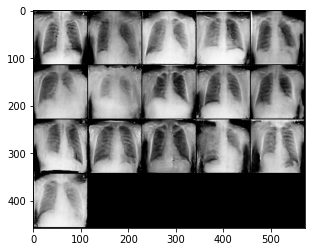

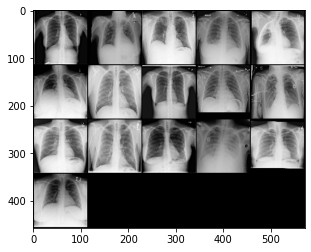

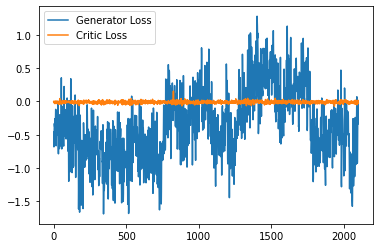

 45%|██████████████████████████████████▊                                           | 2543/5708 [33:01<40:52,  1.29it/s]

Epoch 7, step 42500: Generator loss: -0.3915620230186032, critic loss: -0.003580223312228917


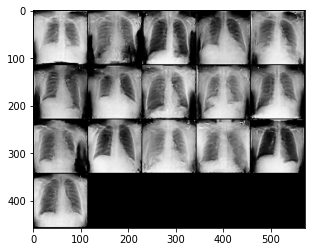

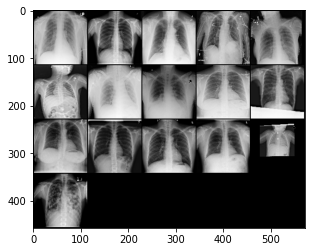

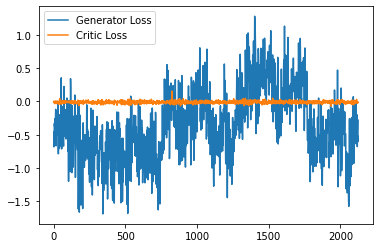

 53%|█████████████████████████████████████████▌                                    | 3043/5708 [39:29<34:23,  1.29it/s]

Epoch 7, step 43000: Generator loss: -0.5015326132241171, critic loss: 0.00023162908963858902


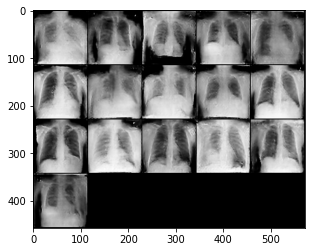

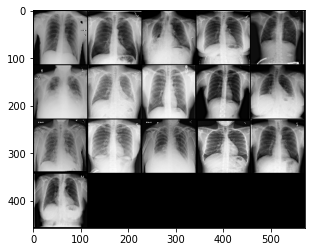

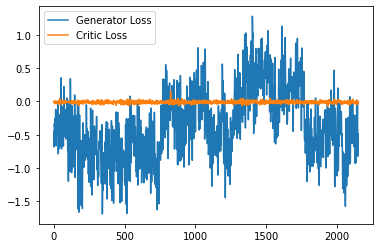

 62%|████████████████████████████████████████████████▍                             | 3543/5708 [45:57<27:56,  1.29it/s]

Epoch 7, step 43500: Generator loss: -0.40625073820876423, critic loss: -0.008945504230074586


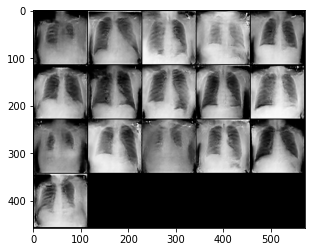

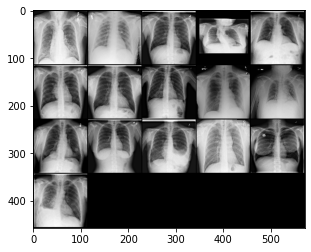

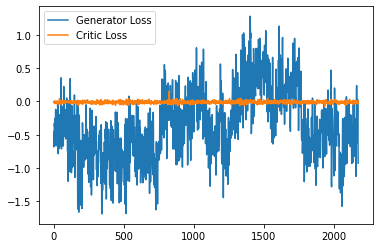

 71%|███████████████████████████████████████████████████████▏                      | 4043/5708 [52:25<21:30,  1.29it/s]

Epoch 7, step 44000: Generator loss: -0.23861519242404028, critic loss: -0.011326050030626363


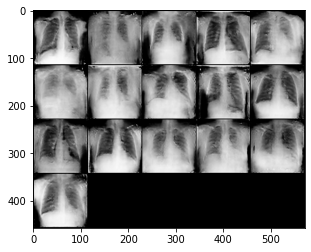

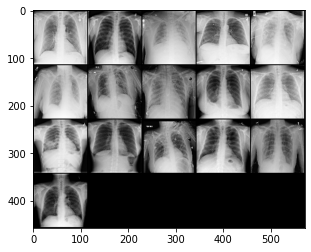

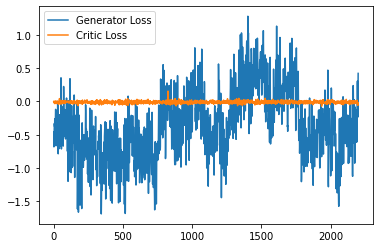

 80%|██████████████████████████████████████████████████████████████                | 4543/5708 [58:53<15:02,  1.29it/s]

Epoch 7, step 44500: Generator loss: 0.19481190137120574, critic loss: -0.0070616182947531286


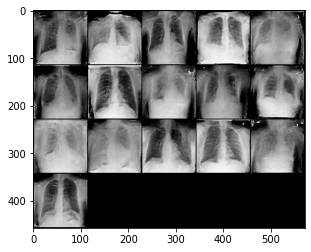

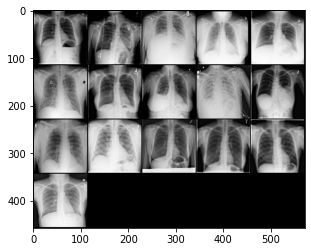

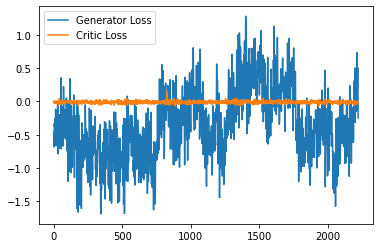

 88%|███████████████████████████████████████████████████████████████████▏        | 5043/5708 [1:05:21<08:34,  1.29it/s]

Epoch 7, step 45000: Generator loss: -0.10953093391447329, critic loss: -0.00751188304014504


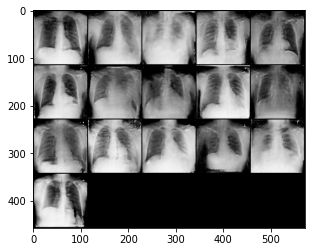

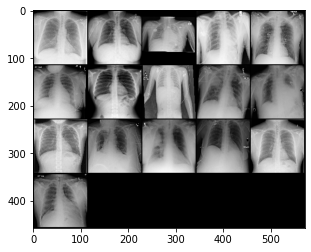

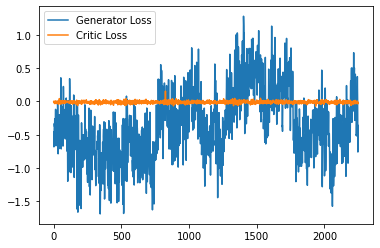

 97%|█████████████████████████████████████████████████████████████████████████▊  | 5543/5708 [1:11:49<02:08,  1.29it/s]

Epoch 7, step 45500: Generator loss: -0.0049051553059834985, critic loss: -0.00438015355374664


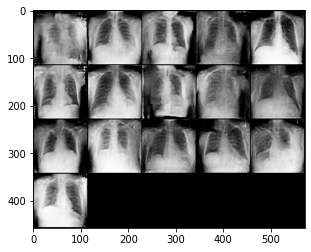

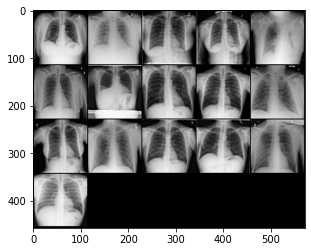

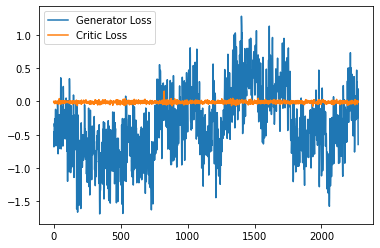

  4%|███▎                                                                         | 249/5708 [03:22<1:14:07,  1.23it/s]


KeyboardInterrupt: 

In [22]:
Gen, Crit, Generator_Optimizer, Critic_Optimizer = GAN(trained, epochs, nDz, nGz, display_step, img_channels, crit_repeats, learning_rate, beta_1, beta_2, lambda_, z_dim, size, numClasses, dataloader, loss, device)

In [21]:
import os
generated = [1000, 200, 300, 100, 1200, 150, 100, 390, 3000, 500, 9610, 500, 200, 50, 400]
folders = os.listdir('NIH Dataset/Images_WCGAN/train')
for idx, folder in enumerate(folders):
    for g in range(generated[idx]):
        images = generate_images(True, 'Weights/Generator_112_W_CGAN_V2.pth', nGz, 1, z_dim, True, 15, 1, size = size, labels = [idx], device = device)
        image_tensor = (images + 1) / 2
        image_unflat = image_tensor.detach().cpu()
        inv_normalize = transforms.Normalize(mean = [-0.5 * 0.5], std = [1 / 0.5])
        image = inv_normalize(image_unflat[0])
        image = image.permute(1, 2, 0).squeeze()
        image = Image.fromarray((image.numpy() * 255).astype(np.uint8), mode = 'L')
        image.save('NIH Dataset/Images_WCGAN/train/' + folder + '/image_' + str(g) + '.png')